# Machine learning for D0 analysis

In [1]:
import numpy as np
import os
import shap
import argparse
import pandas as pd

import xgboost as xgb
import matplotlib.pyplot as plt
import math

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from hipe4ml.model_handler import ModelHandler
from hipe4ml.tree_handler import TreeHandler
from hipe4ml.analysis_utils import train_test_generator
from hipe4ml import plot_utils, analysis_utils

In [3]:
from ROOT import(
    TFile, TFileMerger, TF1, TMath,
    TH1F, TGraph, TMultiGraph, TCanvas, kRed, kGreen, kBlue, kViolet, kMagenta, kOrange, kBlack,
    TLegend, TPaveText,
    gStyle, gDirectory, gPad
)

Welcome to JupyROOT 6.30/04


In [4]:
%matplotlib inline
%jsroot on

# Functions

In [5]:
def get_merged_samples(wdir, samples_dir, filt='Signal'):
    if f'{filt}.root' not in os.listdir(wdir):
        merger = TFileMerger()
        merger.OutputFile(f'{wdir}/{filt}.root', 'RECREATE')
        for f in os.listdir(samples_dir):
            if filt in f: merger.AddFile(os.path.join(samples_dir, f))
        ok = merger.Merge()  
    
    return TFile.Open(f'{wdir}/{filt}.root')
            

In [6]:
def get_data_with_preselections(wdir, preselection_cuts, filt='Signal'):
    if f'{filt}_presel.root' not in os.listdir(wdir):
        f = TFile.Open(f'{wdir}/{filt}.root')
        if filt == 'Signal': t = f.Get('treeMLSig')
        elif filt == 'Bkg':  t = f.Get('treeMLBkg')
        t.SetBranchStatus("mult", 0)
        
        f_presel = TFile(f'{wdir}/{filt}_presel.root', 'RECREATE')
        t_presel = t.CopyTree(preselection_cuts)

        f_presel.cd()
        t_presel.Write()
        f_presel.Close()
    
    return TFile.Open(f'{wdir}/{filt}_presel.root')

In [7]:
def get_data_for_y_pt_slice(wdir, presel_dir='', y_pt_lim=[[-1,1],[2,3]], filt='Signal'):
    if presel_dir=='': presel_dir = wdir
    ymin = y_pt_lim[0][0]
    ymax = y_pt_lim[0][1]
    ptmin = y_pt_lim[1][0]
    ptmax = y_pt_lim[1][1]
    if f'{filt}_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}.root' not in os.listdir(wdir):
        f = TFile.Open(f'{presel_dir}/{filt}_presel.root')
        if filt == 'Signal': t = f.Get('treeMLSig')
        elif filt == 'Bkg':  t = f.Get('treeMLBkg')
        
        f_slice = TFile(f'{wdir}/{filt}_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}.root', 'RECREATE')
        
        y_pt_selection = f'(y_D0>{ymin} && y_D0<{ymax}) && (pt_D0>{ptmin} && pt_D0<{ptmax})'
        t_slice = t.CopyTree(y_pt_selection)

        f_slice.cd()
        t_slice.Write()
        f_slice.Close()
    
    return TFile.Open(f'{wdir}/{filt}_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}.root')

In [8]:
def get_resampled_signal(wdir, ymin=-2.0, ymax=3.0, ptmin=1.0, ptmax=100.0,
                         nEvents_D0Sample=9.85e5, nTotalEvents=4.72162e9, nExpected_D0=0, ml='before_ml'):
    if f'resampled_signal_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root' not in os.listdir(wdir):
        _sample_signal(wdir, ymin, ymax, ptmin, ptmax, nEvents_D0Sample, nTotalEvents, nExpected_D0, ml)
    
    return TFile.Open(f'{wdir}/resampled_signal_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root')

In [9]:
def get_resampled_bkg(wdir, ymin=-2.0, ymax=3.0, ptmin=1.0, ptmax=100.0,
                      nEvents_DISSample=4.97e6, nTotalEvents=4.72162e9, nExpected_bkg=0, ml='before_ml'):
    if f'resampled_bkg_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root' not in os.listdir(wdir):
        _sample_bkg(wdir, ymin, ymax, ptmin, ptmax, nEvents_DISSample, nTotalEvents, nExpected_bkg, ml)
    
    return TFile.Open(f'{wdir}/resampled_bkg_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root')

## Data resampling

In [1]:
# Create samples for signal by pT and y bins
def studentTPeak(x, par):
    norm = par[0]
    mean = par[1]
    width = par[2]
    n = par[3]

    t = (x[0] - mean) / width
    val = norm * TMath.Gamma((n + 1) / 2.0) / (
        np.sqrt(n * np.pi) * width * TMath.Gamma(n / 2.0)
    ) * pow(1 + t * t / n, -(n + 1) / 2.0)
    return val


def pol2Fit(x, par):
    a, b, c = par[0], par[1], par[2]
    return a + b * x[0] + c * x[0] * x[0]

def _sample_signal(wdir, ymin, ymax, ptmin, ptmax, nEvents_D0Sample, nTotalEvents, nExpected_D0, ml):
    # Style setup
    gStyle.SetPalette(1)
    gStyle.SetOptTitle(1)
    gStyle.SetTitleOffset(1.2, "X")
    gStyle.SetTitleOffset(1.6, "Y")
    gStyle.SetTitleSize(0.04, "X")
    gStyle.SetTitleSize(0.04, "Y")
    gStyle.SetLabelSize(0.04, "X")
    gStyle.SetLabelSize(0.04, "Y")
    gStyle.SetHistLineWidth(2)
    gStyle.SetOptFit(1)
    gStyle.SetOptStat(1)
    gStyle.SetMarkerSize(1.3)
    gStyle.SetStatW(0.12)
    gStyle.SetStatH(0.12)
    gStyle.SetStatX(0.95)
    gStyle.SetStatY(0.95)

    # Output ROOT file
    fout_name = f"{wdir}/resampled_signal_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root"
    fout = TFile(fout_name, "RECREATE")

    c1 = TCanvas("c1", "c1", 0, 52, 1400, 1000)
    c1.SetGrid()
    c1.SetMargin(0.10, 0.03, 0.12, 0.07)

    std_cuts = "(mass_D0 > 1.6 && mass_D0 < 2.5) && d0xy_pi>0.02 && d0xy_k>0.02 && dca_12 < 0.07 && costheta > 0.95 && decay_length > 0.05 && dca_D0 < 0.1"
    min_mass, max_mass = 1.6, 2.5
    nTotalPar = 4

    # Load D0 signal sample
    # if 'Signal_presel.root' not in os.listdir(wdir):  # wdir is in data_after_ML
    #     f_sig_D0sample = TFile.Open(f"{wdir}/../../data_before_ML/sig_data/Signal_presel.root")
    # else:
    #     f_sig_D0sample = TFile.Open(f"{wdir}/Signal_presel.root")
    f_sig_D0sample = TFile.Open(f"{wdir}/../../../data_before_ML/sig_data/Signal_presel.root")
    t_sig_D0sample = f_sig_D0sample.Get("treeMLSig")

    # Apply kinematic and standard cuts
    if ymax > 0.5:
        cut_expr = f"(y_D0>{ymin} && y_D0<{ymax}) && (pt_D0>{ptmin} && pt_D0<{ptmax})"
    else:
        cut_expr = f"(y_D0>{ymin} && y_D0<{ymax}) && (pt_D0>{ptmin} && pt_D0<{ptmax}) && {std_cuts}"

    t_sig_D0sample.Draw("mass_D0>>h_D0Sample(200,1.6,2.5)", cut_expr, "goff")
    h0_D0Sample = gDirectory.Get("h_D0Sample")
    h0_D0Sample.SetMarkerColor(kGreen + 2)

    # Expected number of events
    if nExpected_D0 == 0:  # compute dynamically
        nExpected_D0 = int((nTotalEvents / nEvents_D0Sample) * h0_D0Sample.GetEntries())

    # Define fit function
    fitFunc = TF1("fitFunc", studentTPeak, min_mass, max_mass, nTotalPar)
    fitFunc.SetParNames("Norm", "Mean", "Width", "nDOF")

    c1.cd()
    c1.SetLogy()
    h0_D0Sample.SetMarkerColor(kBlack)
    h0_D0Sample.SetLineColor(kBlack)
    h0_D0Sample.SetMarkerStyle(20)
    h0_D0Sample.SetMarkerSize(2.0)
    h0_D0Sample.SetTitle(f"(y_D0>{ymin:.1f} && y_D0<{ymax:.1f}) && (pt_D0>{ptmin:.1f} && pt_D0<{ptmax});"
                         "Invmass m_{D^{0}} (GeV/c^{2}); Entries (a.u.)")
    h0_D0Sample.SetMaximum(h0_D0Sample.GetMaximum() * 2.0)
    h0_D0Sample.Draw("EP")

    # Initial fit parameters
    fitFunc.SetParameters(100, 1.865, 0.01, 5)
    fitFunc.SetParLimits(3, 1, 10)
    fitFunc.SetParLimits(1, 1.84, 1.89)
    fitFunc.SetParLimits(2, 0.001, 0.1)

    # Fit
    h0_D0Sample.Fit(fitFunc, "NR")
    h0_D0Sample.Fit(fitFunc, "R")

    # Generate expected distribution
    h0_expect_D0Sample = h0_D0Sample.Clone("hData_D0")
    h0_expect_D0Sample.Reset()

    for _ in range(nExpected_D0):
        random_val = fitFunc.GetRandom()
        h0_expect_D0Sample.Fill(random_val)

    h0_expect_D0Sample.SetMarkerColor(kGreen + 2)
    h0_expect_D0Sample.SetLineColor(kGreen + 2)
    h0_expect_D0Sample.Draw("EP same")

    c1.Modified()
    c1.Update()

    stats = h0_expect_D0Sample.FindObject("stats")
    if stats:
        stats.SetX1NDC(stats.GetX1NDC() - 0.23)
        stats.SetX2NDC(stats.GetX2NDC() - 0.23)
        stats.SetTextColor(kGreen + 2)
        c1.Modified()
        c1.Update()

    lsample = TLegend(0.13, 0.80, 0.33, 0.92)
    lsample.SetTextSize(0.03)
    lsample.SetBorderSize(0)
    lsample.AddEntry(h0_D0Sample, "Signal_D0_Sample")
    lsample.AddEntry(h0_expect_D0Sample, "Expected_D0_DIS")
    lsample.Draw()

    c1.SaveAs(f"{wdir}/resampled_signal_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.pdf")
    
    # Save fit params
    fit_params = {}
    fit_params["norm"] = fitFunc.GetParameter("Norm")
    fit_params["norm_err"] = fitFunc.GetParError(fitFunc.GetParNumber("Norm"))
    fit_params["mean"] = fitFunc.GetParameter("Mean")
    fit_params["mean_err"] = fitFunc.GetParError(fitFunc.GetParNumber("Mean"))
    fit_params["width"] = fitFunc.GetParameter("Width")
    fit_params["width_err"] = fitFunc.GetParError(fitFunc.GetParNumber("Width"))
    fit_params["nDOF"] = fitFunc.GetParameter("nDOF")
    fit_params["nDOF_err"] = fitFunc.GetParError(fitFunc.GetParNumber("nDOF"))
    fit_params["ndf"] = fitFunc.GetNDF()
    fit_params["chi2"] = fitFunc.GetChisquare()
    np.save(f"{wdir}/signal_fit_params_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}", fit_params)
    
    # Save sampling statistics
    sample_stats = {}
    sample_stats["sample_events"] = nEvents_D0Sample
    sample_stats["sample_sig_candidates"] = h0_D0Sample.GetEntries()
    sample_stats["expected_events"] = nTotalEvents
    sample_stats["expected_sig_candidates"] = nExpected_D0
    sample_stats["kinematics"] = {}
    sample_stats["kinematics"]["ymin"] = ymin
    sample_stats["kinematics"]["ymax"] = ymax
    sample_stats["kinematics"]["ptmin"] = ptmin
    sample_stats["kinematics"]["ptmax"] = ptmax
    np.save(f"{wdir}/signal_sampling_stats_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}", sample_stats)

    # Write output ROOT file with inv mass hist
    fout.cd()
    h0_expect_D0Sample.SetName("hData_D0")
    h0_expect_D0Sample.Write()
    fout.Close()

In [11]:
def pol2Fit(x, par):
    """2nd-order polynomial fit function"""
    a, b, c = par[0], par[1], par[2]
    return a + b * x[0] + c * x[0] * x[0]

def _sample_bkg(wdir, ymin, ymax, ptmin, ptmax, nEvents_DISSample, nTotalEvents, nExpected_bkg, ml):
    # Style settings
    gStyle.SetPalette(1)
    gStyle.SetOptTitle(1)
    gStyle.SetTitleOffset(1.2, "X")
    gStyle.SetTitleOffset(1.6, "Y")
    gStyle.SetTitleSize(0.04, "X")
    gStyle.SetTitleSize(0.04, "Y")
    gStyle.SetLabelSize(0.04, "X")
    gStyle.SetLabelSize(0.04, "Y")
    gStyle.SetHistLineWidth(2)
    gStyle.SetOptFit(1)
    gStyle.SetOptStat(1)
    gStyle.SetMarkerSize(1.3)
    gStyle.SetStatW(0.12)
    gStyle.SetStatH(0.12)
    gStyle.SetStatX(0.95)
    gStyle.SetStatY(0.95)

    # Output ROOT file
    fout = TFile(f"{wdir}/resampled_bkg_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.root", "RECREATE")

    c1 = TCanvas("c1", "c1", 0, 52, 1400, 1000)
    c1.SetGrid()
    c1.SetMargin(0.10, 0.03, 0.12, 0.07)

    std_cuts = "(mass_D0 > 1.6 && mass_D0 < 2.5) && d0xy_pi>0.02 && d0xy_k>0.02 && dca_12 < 0.07 && costheta > 0.95 && decay_length > 0.05 && dca_D0 < 0.1"
    min_mass, max_mass = 1.6, 2.5
    nTotalPar = 3

    # Load DIS bkg sample
    # if 'Bkg_presel.root' not in os.listdir(wdir):  # wdir is in data_after_ML
    #     f_bkg_DISsample = TFile.Open(f"{wdir}/../../data_before_ML/bkg_data/Bkg_presel.root")
    # else:
    #     f_bkg_DISsample = TFile.Open(f"{wdir}/Bkg_presel.root")
    f_bkg_DISsample = TFile.Open(f"{wdir}/../../../data_before_ML/bkg_data/Bkg_presel.root")
    t_bkg_DISsample = f_bkg_DISsample.Get("treeMLBkg")
    
    # Apply cuts
    if ymax > 0.5:
        draw_expr = f"(y_D0>{ymin} && y_D0<{ymax}) && (pt_D0>{ptmin} && pt_D0<{ptmax})"
    else:
        draw_expr = f"(y_D0>{ymin} && y_D0<{ymax}) && (pt_D0>{ptmin} && pt_D0<{ptmax}) && {std_cuts}"

    # Project the histogram
    t_bkg_DISsample.Draw("mass_D0>>h_Bkg_DISSample(200,1.6,2.5)", draw_expr, "goff")
    h0_DIS = gDirectory.Get("h_Bkg_DISSample")
    
    # Expected number of events
    if nExpected_bkg == 0:  # compute dynamically
        nExpected_bkg = int(nTotalEvents / nEvents_DISSample * h0_DIS.GetEntries())

    # Fit setup
    fitFunc = TF1("fitFunc", pol2Fit, min_mass, max_mass, nTotalPar)
    fitFunc.SetParNames("p0", "p1", "p2")
    fitFunc.SetParameters(1.0, 1.0, 1.0)
    fitFunc.FixParameter(2, 0.0)

    # Plot and fit
    c1.cd()
    c1.SetLogy()
    h0_DIS.SetMarkerColor(kBlack)
    h0_DIS.SetLineColor(kBlack)
    h0_DIS.SetMarkerStyle(20)
    h0_DIS.SetMarkerSize(2.0)
    h0_DIS.SetTitle(f"(y_D0>{ymin:.1f} && y_D0<{ymax:.1f}) && (pt_D0>{ptmin:.1f} && pt_D0<{ptmax:.1f});"
                    "Invmass m_{D^{0}} (GeV/c^{2}); Entries (a.u.)")
    h0_DIS.SetMaximum(1.0e6)
    h0_DIS.Draw("EP")
    h0_DIS.Fit(fitFunc, "NR")
    h0_DIS.Fit(fitFunc, "R")

    # Resample histogram
    h0_DIS_Scaled = h0_DIS.Clone("h_Bkg_DISSample_100")
    h0_DIS_Scaled.Reset()
    h0_DIS_Scaled.SetMarkerColor(kGreen+2)
    h0_DIS_Scaled.SetLineColor(kGreen+2)
    h0_DIS_Scaled.SetMarkerStyle(47)
    h0_DIS_Scaled.SetMarkerSize(2.0)

    for _ in range(nExpected_bkg):
        h0_DIS_Scaled.Fill(fitFunc.GetRandom())

    h0_DIS_Scaled.Draw("EP same")

    # Adjust stat box
    c1.Modified(); c1.Update()
    stats = h0_DIS_Scaled.FindObject("stats")
    if stats:
        stats.SetX1NDC(stats.GetX1NDC() - 0.23)
        stats.SetX2NDC(stats.GetX2NDC() - 0.23)
        stats.SetTextColor(kGreen+2)

    # Legend
    legend = TLegend(0.13, 0.80, 0.33, 0.92)
    legend.SetTextSize(0.03)
    legend.SetBorderSize(0)
    legend.AddEntry(h0_DIS, "Bkg_DIS_Sample")
    legend.AddEntry(h0_DIS_Scaled, "Bkg_DIS_Sample Resampled")
    legend.Draw()

    # Save outputs
    c1.SaveAs(f"{wdir}/resampled_bkg_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}.pdf")
    
    # Save fit params
    fit_params = {}
    fit_params["p0"] = fitFunc.GetParameter("p0")
    fit_params["p0_err"] = fitFunc.GetParError(fitFunc.GetParNumber("p0"))
    fit_params["p1"] = fitFunc.GetParameter("p1")
    fit_params["p1_err"] = fitFunc.GetParError(fitFunc.GetParNumber("p1"))
    fit_params["p2"] = fitFunc.GetParameter("p2")
    fit_params["p2_err"] = fitFunc.GetParError(fitFunc.GetParNumber("p2"))
    fit_params["ndf"] = fitFunc.GetNDF()
    fit_params["chi2"] = fitFunc.GetChisquare()
    np.save(f'{wdir}/bkg_fit_params_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}', fit_params)
    
    # Save sampling statistics
    sample_stats = {}
    sample_stats["sample_events"] = nEvents_DISSample
    sample_stats["sample_bkg_candidates"] = h0_DIS.GetEntries()
    sample_stats["expected_events"] = nTotalEvents
    sample_stats["expected_bkg_candidates"] = nExpected_bkg
    sample_stats["kinematics"] = {}
    sample_stats["kinematics"]["ymin"] = ymin
    sample_stats["kinematics"]["ymax"] = ymax
    sample_stats["kinematics"]["ptmin"] = ptmin
    sample_stats["kinematics"]["ptmax"] = ptmax
    np.save(f"{wdir}/bkg_sampling_stats_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}", sample_stats)

    fout.cd()
    h0_DIS_Scaled.SetName("hData_D0")
    h0_DIS_Scaled.Write()
    fout.Close()


## Plotting

In [12]:
def calculate_s_over_b_and_signif(wdir, fsig_resamp, fbkg_resamp, ymin, ymax, ptmin, ptmax, ml='before_ml'):
    # get signal peak
    signal_fit_params = np.load(f'{wdir}/../data_before_ML/sig_data/signal_fit_params_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_before_ml.npy', allow_pickle=True, encoding='latin1').item()
    xlow = signal_fit_params['mean'] - 2 * signal_fit_params['width']
    xhigh = signal_fit_params['mean'] + 2 * signal_fit_params['width']
    print(f'Signal peak range: {xlow:.4f} < mass_D0 < {xhigh:.4f}')
    
    # get resampled data
    hsig = fsig_resamp.Get('hData_D0')
    hbkg = fbkg_resamp.Get('hData_D0')
    
    # calculate S/B and signif
    sigbin_low = hsig.GetXaxis().FindFixBin(xlow)
    sigbin_high = hsig.GetXaxis().FindFixBin(xhigh)

    bkgbin_low = hbkg.GetXaxis().FindFixBin(xlow)
    bkgbin_high = hbkg.GetXaxis().FindFixBin(xhigh)

    num_sig = 0
    num_bkg = 0
    for i in range(sigbin_low, sigbin_high+1):
        num_sig += hsig.GetBinContent(i)
    for i in range(bkgbin_low, bkgbin_high+1):
        num_bkg += hbkg.GetBinContent(i)
    
    s_over_b = num_sig / num_bkg
    signif = num_sig / np.sqrt(num_sig + num_bkg)

    print(f'S/B = {s_over_b:.4f}')
    print(f'Signif = {signif:.4f}')
    
    stats = {}
    stats['s_over_b'] = s_over_b
    stats['signif'] = signif
    np.save(f'{wdir}/s_over_b_and_signif_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_{ml}', stats)
    
    return s_over_b, signif

## ML

In [13]:
def print_optuna_results(study):
    print(f"{'| Trial':<10}| {'Target':<9}| {'learning_rate':<14}| {'max_depth':<10}| {'n_estimators':<14}|")
    print("-" * 70)
    
    for trial in study.trials:
        target = round(trial.value, 4)
        lr = round(trial.params.get('learning_rate', 0), 5)
        depth = int(trial.params.get('max_depth', 0))
        estimators = int(trial.params.get('n_estimators', 0))

        print(f"| {trial.number:<9}| {target:<9}| {lr:<14}| {depth:<10}| {estimators:<14}|")


In [14]:
def get_training_data(wdir, sig, bkg, ymin=-2.0, ymax=3.0, ptmin=1.0, ptmax=100.0):
    # sig = TreeHandler(f'{wdir}/data_before_ML/sig_data/Signal_presel.root','treeMLSig')
    # bkg = TreeHandler(f'{wdir}/data_before_ML/bkg_data/Bkg_presel.root','treeMLBkg')
    
    # Apply preselections for sig and bkg
    selsig_cuts = sig.get_subset(f'(mass_D0 > 1.7 and mass_D0 < 2.1) and (y_D0 > {ymin} and y_D0 < {ymax}) and (pt_D0 > {ptmin} and pt_D0 < {ptmax})')
    selbkg_cuts = bkg.get_subset(f'(1.6 < mass_D0 < 1.7 or 2.1 < mass_D0 < 2.5) and (y_D0 > {ymin} and y_D0 < {ymax}) and (pt_D0 > {ptmin} and pt_D0 < {ptmax})')
    
    # Resize sig and bkg datasets
    n_sig = selsig_cuts.get_n_cand()
    n_bkg = selbkg_cuts.get_n_cand()
    min_size = min(n_sig, n_bkg)
    
    selsig = selsig_cuts.get_subset(size=min_size)
    selbkg = selbkg_cuts.get_subset(size=min_size)
    
    print(f'Sig candidates for ML training: {selsig.get_n_cand()}')
    print(f'Bkg candidates for ML training: {selbkg.get_n_cand()}')
    
    return selsig, selbkg

# Home directory

Set the directory to save all files produced in this notebook.

In [42]:
# homedir = 'ML_by_slices/ML_example_results'
homedir = 'ML_by_slices/ML_test'

# Data preparation

Prepare data files for signal and background candidates to analyze.

In [19]:
# locations to save prepared sig and bkg data
os.makedirs(f'{homedir}/data_before_ML/sig_data', exist_ok=True)
os.makedirs(f'{homedir}/data_before_ML/bkg_data', exist_ok=True)

In [16]:
# locations of root files from analysis of D0 and DIS samples
samples_D0 = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_D0_10x100_minQ2_1_25.10.3'
samples_DIS = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_DIS_10x100_minQ2_1_25.10.0'

In [17]:
# locations to save prepared sig and bkg data
sig_dir = f'{homedir}/data_before_ML/sig_data'
bkg_dir = f'{homedir}/data_before_ML/bkg_data'

In [18]:
# locations of root files from analysis of D0 and DIS samples
D0_dir = samples_D0
DIS_dir = samples_DIS

## Combine signal and bkg root files

In [174]:
# locations to save prepared sig and bkg data
os.makedirs(f'{homedir}/data_before_ML/sig_data', exist_ok=True)
os.makedirs(f'{homedir}/data_before_ML/bkg_data', exist_ok=True)

In [209]:
fsig = get_merged_samples(sig_dir, D0_dir, filt='Signal')

In [210]:
fbkg = get_merged_samples(bkg_dir, DIS_dir, filt='Bkg')

In [211]:
fD0_sample = get_merged_samples(sig_dir, D0_dir, filt='output')

In [212]:
fDIS_sample = get_merged_samples(bkg_dir, DIS_dir, filt='output')

In [213]:
tsig = fsig.Get("treeMLSig")
tsig.SetBranchStatus("mult", 0)

tbkg = fbkg.Get("treeMLBkg")
tbkg.SetBranchStatus("mult", 0)

num_sig = tsig.GetEntries()
num_bkg = tbkg.GetEntries()

print(f'Ratio of sig/bkg candidates: {num_sig} / {num_bkg} = {num_sig/num_bkg:.4f}')

Ratio of sig/bkg candidates: 551999 / 1919466 = 0.2876


In [214]:
c = TCanvas()
hsig = TH1F('sig', '', 100, 1.5, 2.5)
hbkg = TH1F('bkg', '', 100, 1.5, 2.5)
tsig.Draw("mass_D0 >> sig", "", "goff")
tbkg.Draw("mass_D0 >> bkg", "", "goff")

# hsig.SetMaximum(1e7)
hsig.Draw()
hbkg.Draw('same')
c.Draw()

## Apply preselections

In [215]:
preselection_cuts='(mass_D0 > 1.6 && mass_D0 < 2.5) && (d0xy_pi>0.02 && d0xy_pi<10.) && (d0xy_k>0.02 && d0xy_k<10.) && decay_length <100.'

In [216]:
fsig_presel = get_data_with_preselections(sig_dir, preselection_cuts, filt='Signal')

In [217]:
fbkg_presel = get_data_with_preselections(bkg_dir, preselection_cuts, filt='Bkg')

In [218]:
tsig_presel = fsig_presel.Get("treeMLSig")
# tsig_presel.SetBranchStatus("mult", 0)

tbkg_presel = fbkg_presel.Get("treeMLBkg")
# tbkg_presel.SetBranchStatus("mult", 0)

num_sig_presel = tsig_presel.GetEntries()
num_bkg_presel = tbkg_presel.GetEntries()

print(f'Ratio of sig/bkg candidates after preselections: {num_sig_presel} / {num_bkg_presel} = {num_sig_presel/num_bkg_presel:.4f}')

Ratio of sig/bkg candidates after preselections: 405511 / 188813 = 2.1477


### y and pT distributions total

In [219]:
c = TCanvas()
hsig = TH1F('sig', '', 100, -3., 4.)
hbkg = TH1F('bkg', '', 100, -3., 4.)
tsig_presel.Draw("y_D0 >> sig", "", "goff")
tbkg_presel.Draw("y_D0 >> bkg", "", "goff")

hbkg.SetLineColor(kRed)
# hsig.SetMaximum(1e7)
hsig.GetXaxis().SetTitle('y_{D^{0}}')

l = TLegend(0.5, 0.8, 0.8, 0.9)
l.AddEntry(hsig, 'Signal')
l.AddEntry(hbkg, 'Background')
l.SetTextSize(0.03)
l.SetBorderSize(0)
# l.Draw()

hsig.SetStats(0)
hsig.SetTitle('y of D^{0} particles')
hsig.GetYaxis().SetTitle('Fraction of total signal candidates')

hsig.Scale(1/hsig.GetEntries())
hsig.SetMarkerStyle(20)
hsig.SetMarkerSize(0.7)

hsig.Draw()
# hbkg.Draw('same')
c.Draw()
c.Print('/home/cy7423/eic/ML_by_slices/D0_y.pdf')

Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/D0_y.pdf has been created


In [33]:
c = TCanvas()
hsig = TH1F('sig', '', 100, 0., 5.)
hbkg = TH1F('bkg', '', 100, 0., 5.)
tsig_presel.Draw("pt_D0 >> sig", "", "goff")
tbkg_presel.Draw("pt_D0 >> bkg", "", "goff")

hbkg.SetLineColor(kRed)
# hsig.SetMaximum(1e7)
hsig.GetXaxis().SetTitle('p_{T,D^{0}} (GeV/c)')

l = TLegend(0.5, 0.8, 0.8, 0.9)
l.AddEntry(hsig, 'Signal')
l.AddEntry(hbkg, 'Background')
l.SetTextSize(0.03)
l.SetBorderSize(0)
# l.Draw()

hsig.SetStats(0)
hsig.SetTitle('p_{T} of D^{0} particles')
hsig.GetYaxis().SetTitle('Fraction of total signal candidates')

hsig.Scale(1/hsig.GetEntries())
hsig.SetMarkerStyle(20)
hsig.SetMarkerSize(0.7)

hsig.Draw()
# hbkg.Draw('same')
c.Draw()
c.Print('/home/cy7423/eic/ML_by_slices/D0_pT.pdf')

Warning in <TFile::Append>: Replacing existing TH1: sig (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: bkg (Potential memory leak).
Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/D0_pT.pdf has been created


### Top variable distributions total

In [36]:
h = TH1F('d0xy_pi','d0xy_pi',100,0.,2000.)
for e in tsig_presel:
    h.Fill(tsig_presel.d0xy_pi)

c = TCanvas()
h.Draw()
c.Draw()

In [36]:
h = TH1F('d0xy_pi','d0xy_pi',100,0.,100.)
for e in tbkg:
    h.Fill(tbkg.d0xy_pi)

c = TCanvas()
h.Draw()
c.Draw()

Warning in <TFile::Append>: Replacing existing TH1: d0xy_pi (Potential memory leak).


In [37]:
h = TH1F('d0xy_k','d0xy_k',100,0.,100.)
for e in tsig:
    h.Fill(tsig.d0xy_k)

c = TCanvas()
h.Draw()
c.Draw()

In [38]:
h = TH1F('decay_length','decay_length',100,0.,300.)
for e in tsig:
    h.Fill(tsig.decay_length)

c = TCanvas()
h.Draw()
c.Draw()

## Create y and pT slices

In [20]:
wdir = homedir

In [21]:
# locations of total sig and bkg data
sigtot_dir = f'{homedir}/data_before_ML/sig_data'
bkgtot_dir = f'{homedir}/data_before_ML/bkg_data'

In [22]:
# locations of root files from analysis of D0 and DIS samples
samples_D0 = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_D0_10x100_minQ2_1_25.10.3'
samples_DIS = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_DIS_10x100_minQ2_1_25.10.0'

D0_dir = samples_D0
DIS_dir = samples_DIS

In [37]:
yslices = [[-1,1], [1,3]]
ptslices = [[0,1], [1,2], [2,3]]

In [38]:
for i in range(len(yslices)):
    for j in range(len(ptslices)):
        ymin = yslices[i][0]
        ymax = yslices[i][1]
        ptmin = ptslices[j][0]
        ptmax = ptslices[j][1]
        
        # locations to save resampled data by y and pT slice
        sigdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/sig_data'
        bkgdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/bkg_data'
        os.makedirs(sigdir, exist_ok=True)
        os.makedirs(bkgdir, exist_ok=True)
        
        # create sig and bkg root files for each slice
        fsig_slice = get_data_for_y_pt_slice(sigdir, sigtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Signal')
        fbkg_slice = get_data_for_y_pt_slice(bkgdir, bkgtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Bkg')

In [39]:
ymin = 1
ymax = 3
ptmin = 1
ptmax = 2

In [28]:
sigdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/sig_data'
bkgdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/bkg_data'
    
fsig_slice = get_data_for_y_pt_slice(sigdir, sigtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Signal')
fbkg_slice = get_data_for_y_pt_slice(bkgdir, bkgtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Bkg')

In [29]:
tsig_slice = fsig_slice.Get("treeMLSig")
tbkg_slice = fbkg_slice.Get("treeMLBkg")

num_sig = tsig_slice.GetEntries()
num_bkg = tbkg_slice.GetEntries()

print(f'Ratio of sig/bkg candidates for ({ymin} < y < {ymax}) & ({ptmin} < pT < {ptmax}): \n\t {num_sig} / {num_bkg} = {num_sig/num_bkg:.4f}')

Ratio of sig/bkg candidates for (1 < y < 3) & (1 < pT < 2): 
	 82264 / 34213 = 2.4045


### y and pT distributions

In [40]:
c = TCanvas()
hsig = TH1F('sig', '', 100, -3., 4.)
hbkg = TH1F('bkg', '', 100, -3., 4.)
tsig_slice.Draw("y_D0 >> sig", "", "goff")
tbkg_slice.Draw("y_D0 >> bkg", "", "goff")

hbkg.SetLineColor(kRed)  # bkg

# hsig.SetMaximum(1e7)
hsig.Draw()
hbkg.Draw('same')
c.Draw()

In [41]:
c = TCanvas()
hsig = TH1F('sig', '', 100, 0., 5.)
hbkg = TH1F('bkg', '', 100, 0., 5.)
tsig_slice.Draw("pt_D0 >> sig", "", "goff")
tbkg_slice.Draw("pt_D0 >> bkg", "", "goff")

hbkg.SetLineColor(kRed)  # bkg

# hsig.SetMaximum(1e7)
hsig.Draw()
hbkg.Draw('same')
c.Draw()

Warning in <TFile::Append>: Replacing existing TH1: sig (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: bkg (Potential memory leak).


### Top variable distributions

In [37]:
h = TH1F('signif_d0xy_pi','signif_d0xy_pi',100,0.,10.)
for e in tsig_slice:
    h.Fill(tsig_slice.signif_d0xy_pi)
    
hb = TH1F('signif_d0xy_pi','signif_d0xy_pi',100,0.,10.)
for e in tbkg_slice:
    hb.Fill(tbkg_slice.signif_d0xy_pi)

hb.SetLineColor(kRed)  # bkg

c = TCanvas()
h.Draw()
hb.Draw('same')
c.Draw()

Warning in <TFile::Append>: Replacing existing TH1: signif_d0xy_pi (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: signif_d0xy_pi (Potential memory leak).


# D0 inv mass before ML

Check invariant mass plots before ML.

In [23]:
# locations of root files from analysis of D0 and DIS samples
samples_D0 = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_D0_10x100_minQ2_1_25.10.3'
samples_DIS = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_DIS_10x100_minQ2_1_25.10.0'

D0_dir = samples_D0
DIS_dir = samples_DIS

In [480]:
yslices = [[-1,1], [1,3]]
ptslices = [[0,0.5], [0,1], [1,2], [2,3]]

In [481]:
# locations to save resampled data by y and pT slice
for i in range(len(yslices)):
    for j in range(len(ptslices)):
        ymin = yslices[i][0]
        ymax = yslices[i][1]
        ptmin = ptslices[j][0]
        ptmax = ptslices[j][1]
        
        sigdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/sig_data'
        bkgdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/bkg_data'
        os.makedirs(sigdir, exist_ok=True)
        os.makedirs(bkgdir, exist_ok=True)

In [482]:
sig_dir = f'{homedir}/data_before_ML/sig_data'
bkg_dir = f'{homedir}/data_before_ML/bkg_data'

In [483]:
fsig = get_merged_samples(sig_dir, D0_dir, filt='Signal')
fbkg = get_merged_samples(bkg_dir, DIS_dir, filt='Bkg')

tsig = fsig.Get("treeMLSig")
tsig.SetBranchStatus("mult", 0)

tbkg = fbkg.Get("treeMLBkg")
tbkg.SetBranchStatus("mult", 0)

## Resample data by y and pT slice

In [24]:
# locations of root files from analysis of D0 and DIS samples
samples_D0 = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_D0_10x100_minQ2_1_25.10.3'
samples_DIS = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_DIS_10x100_minQ2_1_25.10.0'

D0_dir = samples_D0
DIS_dir = samples_DIS

In [485]:
# locations to save prepared sig and bkg data
sig_dir = f'{homedir}/data_before_ML/sig_data'
bkg_dir = f'{homedir}/data_before_ML/bkg_data'

In [25]:
nTotalEvents = 4.72162e9 # expected for 10 fb^-1

In [26]:
scale_D0 = 1821.83  # additional scaling factor for D0 candidates

In [488]:
fD0_sample = get_merged_samples(sig_dir, D0_dir, filt='output')
fDIS_sample = get_merged_samples(bkg_dir, DIS_dir, filt='output')

In [489]:
# get total number of resampled event
hevents_DIS = fDIS_sample.Get('hEventStat')
num_events_DIS = hevents_DIS.GetBinContent(1)
print(f'Total DIS events: {num_events_DIS}')

hevents_D0 = fD0_sample.Get('hEventStat')
num_events_D0 = hevents_D0.GetBinContent(1)
print(f'Total D0 events: {num_events_D0}')

nEvents_D0Sample = int(num_events_D0 * scale_D0)
print(f'Total scaled D0 events in sample: {nEvents_D0Sample}')

Total DIS events: 4968067.0
Total D0 events: 985468.0
Total scaled D0 events in sample: 1795355166


In [490]:
yslices = [[-1,1], [1,3]]
# ptslices = [[0,0.5], [0,1], [1,2], [2,3]]
ptslices = [[0,1], [1,2], [2,3]]

In [ ]:
for i in range(len(yslices)):
    for j in range(len(ptslices)):
        ymin = yslices[i][0]
        ymax = yslices[i][1]
        ptmin = ptslices[j][0]
        ptmax = ptslices[j][1]
        print(f'({ymin} < y < {ymax}) & ({ptmin} < pT < {ptmax}):')
        
        # locations to save resampled data by y and pT slice
        sigdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/sig_data'
        bkgdir = f'{wdir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/data_before_ML/bkg_data'
        
        fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                           nEvents_D0Sample=nEvents_D0Sample, nTotalEvents=nTotalEvents)
        fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                        nEvents_DISSample=num_events_DIS, nTotalEvents=nTotalEvents)
        
        hsig = fsig_resamp.Get('hData_D0')
        hbkg = fbkg_resamp.Get('hData_D0')
        
        print(f'Resampled sig/bkg candidates: {hsig.GetEntries()} / {hbkg.GetEntries()} = {hsig.GetEntries()/hbkg.GetEntries():.4f}')  
        print('---------------------------------------------')

## Plot inv mass

In [50]:
ymin = 1
ymax = 3
ptmin = 1
ptmax = 2

In [44]:
wdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}'

In [45]:
os.makedirs(f'{wdir}/data_before_ML', exist_ok=True)

In [59]:
s_over_b, signif = calculate_s_over_b_and_signif(f'{wdir}/data_before_ML', fsig_resamp, fbkg_resamp,
                                                ymin, ymax, ptmin, ptmax)

Signal peak range: 1.8483 < mass_D0 < 1.8812
S/B = 0.1704
Signif = 66.3496


In [60]:
c = TCanvas()
hsig.SetMaximum(1e5)
hsig.GetXaxis().SetTitleOffset(1)
hsig.GetYaxis().SetTitleOffset(1.2)
hsig.Draw('hist')
hbkg.Draw('hist same')
c.Draw()
# c.Print(f'{wdir}/data_before_ML/inv_mass_sig_and_bkg.pdf')

In [61]:
c = TCanvas()
h = hsig.Clone()
h.Add(hbkg)

# set styles
h.SetMarkerStyle(20)
h.SetMarkerSize(0.7)
h.SetMarkerColor(kBlack)
h.SetLineColor(kBlack)

h.SetTitle(f'With machine bkg ({ymin} < y < {ymax}, {ptmin} < pt < {ptmax})')
h.GetXaxis().SetTitleOffset(1)
h.GetYaxis().SetTitleOffset(1.2)

h.Draw('e0')
h.Draw('p same')

# legend
l = TLegend(0.45, 0.8, 0.7, 0.87)
l.AddEntry(h, 'no top. cuts')
l.SetTextSize(0.03)
l.SetBorderSize(0)
l.Draw()

# text
t = TPaveText(0.45, 0.7, 0.6, 0.8, "NDC")
t.SetFillColor(0)
t.SetBorderSize(0)
t.SetTextFont(42)
t.SetTextSize(0.03)
t.SetTextAlign(13)
t.AddText(f"S/B = {s_over_b:.2f}")
t.AddText(f"Signif = {signif:.2f}")
t.Draw()

# gPad.SetLogy()
c.Draw()
# c.Print(f'{wdir}/data_before_ML/inv_mass_combined_sig_plus_bkg.pdf')

# Machine learning

Train BDT model and obtain results.

In [28]:
ymin = 1
ymax = 3
ptmin = 1
ptmax = 2

In [29]:
# yslices = [[-1,1], [1,3]]
# ptslices = [[0,1], [1,2], [2,3]]

# ymin = yslices[0][0]
# ymax = yslices[0][1]
# ptmin = ptslices[1][0]
# ptmax = ptslices[1][1]

In [30]:
print(f'ymin: {ymin} \nymax: {ymax} \nptmin: {ptmin} \nptmax: {ptmax}')

ymin: 1 
ymax: 3 
ptmin: 1 
ptmax: 2


In [31]:
wdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}'

In [32]:
# location to save ML outputs
os.makedirs(f'{wdir}/ML', exist_ok=True)

In [33]:
sig = TreeHandler(f'{wdir}/../data_before_ML/sig_data/Signal_presel.root','treeMLSig')
bkg = TreeHandler(f'{wdir}/../data_before_ML/bkg_data/Bkg_presel.root','treeMLBkg')
print(f'Available sig candidates: {sig.get_n_cand()}')
print(f'Available bkg candidates: {bkg.get_n_cand()}')

Available sig candidates: 405511
Available bkg candidates: 188813


In [34]:
selsig, selbkg = get_training_data(wdir, sig, bkg, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax)  # after preselections and resizing

Sig candidates for ML training: 16703
Bkg candidates for ML training: 16703


In [35]:
train_test_data = train_test_generator([selsig, selbkg], [1,0], test_size=0.2, random_state=42)

In [36]:
selsig.get_var_names()

['d0_pi',
 'd0_k',
 'd0xy_pi',
 'd0xy_k',
 'sum_d0xy',
 'dca_12',
 'dca_D0',
 'pt_D0',
 'y_D0',
 'mass_D0',
 'decay_length',
 'costheta',
 'costheta_xy',
 'sigma_vtx',
 'signif_d0xy_pi',
 'signif_d0xy_k']

In [37]:
vars_to_draw = selsig.get_var_names()
features_for_train = ['costheta',
                      # 'costheta_xy',
                      'dca_D0',
                      # 'dca_12',  # redundant with sigma_vtx
                      # 'd0_pi',
                      # 'd0_k',
                      # 'd0xy_pi',  # redundant with signif_d0xy_pi
                      # 'd0xy_k',  # redundant with signif_d0xy_k
                      # 'sum_d0xy',  # redundant with signif_d0xy_pi and signif_d0xy_k
                      'signif_d0xy_pi',
                      'signif_d0xy_k',
                      # 'decay_length',
                      'sigma_vtx',
                     ]

print('Variables used in machine learning:')
print(features_for_train)

Variables used in machine learning:
['costheta', 'dca_D0', 'signif_d0xy_pi', 'signif_d0xy_k', 'sigma_vtx']


In [38]:
leg_labels = ['Background', 'Signal']

## Features

In [403]:
# location to save feature plots
os.makedirs(f'{wdir}/ML/features', exist_ok=True)

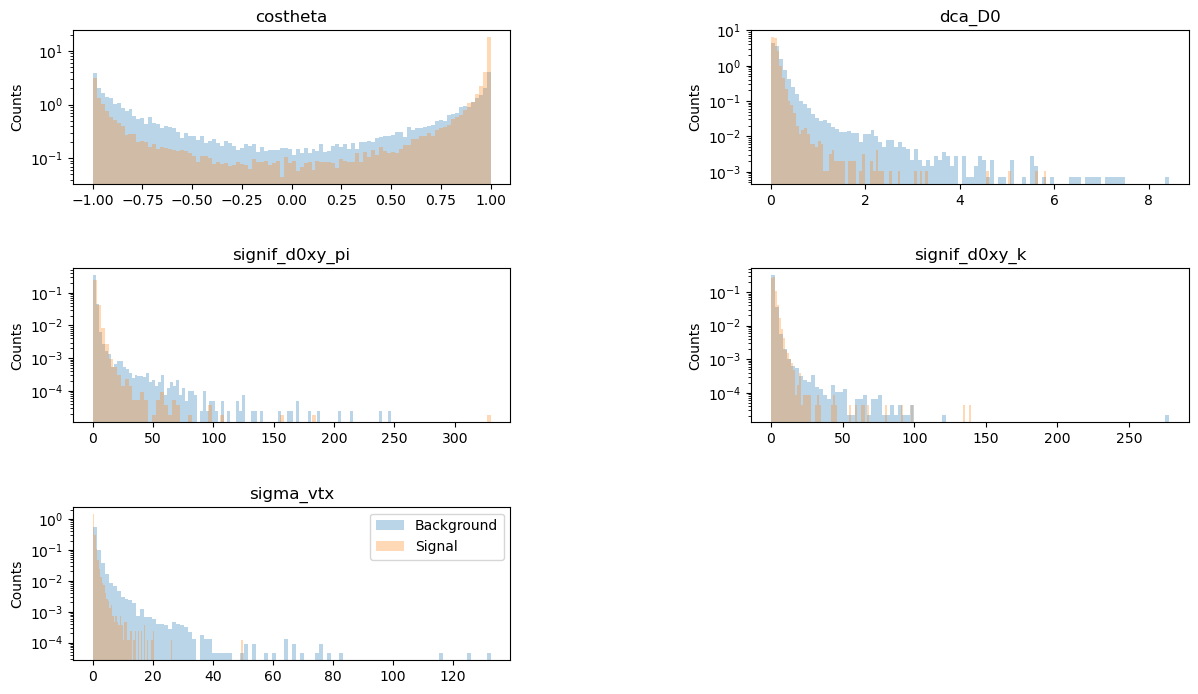

In [404]:
leg_labels = ['Background', 'Signal']
plot_utils.plot_distr([selbkg, selsig], features_for_train, bins=100, labels=leg_labels, log=True, density=True, figsize=(12, 7), alpha=0.3, grid=False)
plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
plt.savefig(f'{wdir}/ML/features/sig_bkg_distributions_plot_features_to_train.png') 
plt.show()
plt.close() 

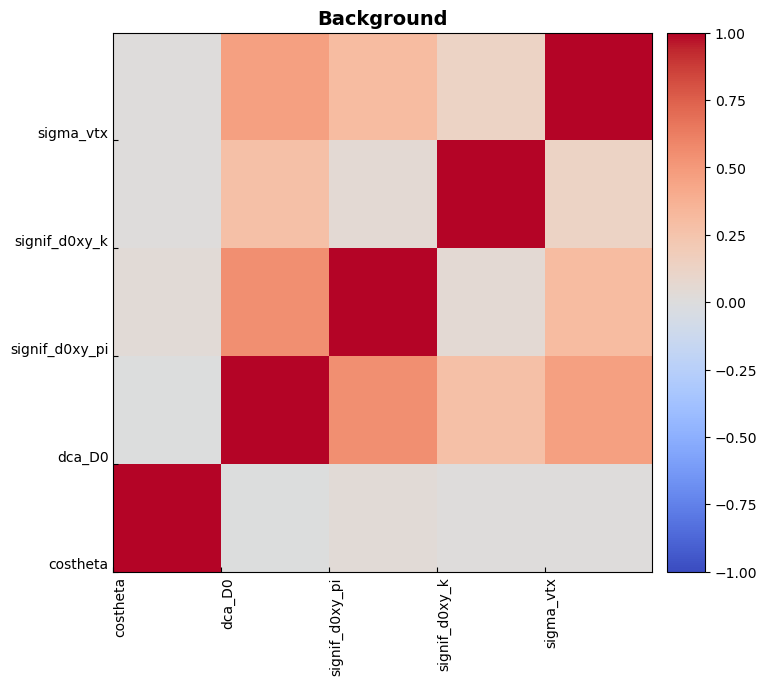

In [405]:
plot_utils.plot_corr([selbkg, selbkg], features_for_train, leg_labels[:1])
plt.savefig(f'{wdir}/ML/features/correlation_plot_bkg.png', bbox_inches='tight')
plt.show()
plt.close() 

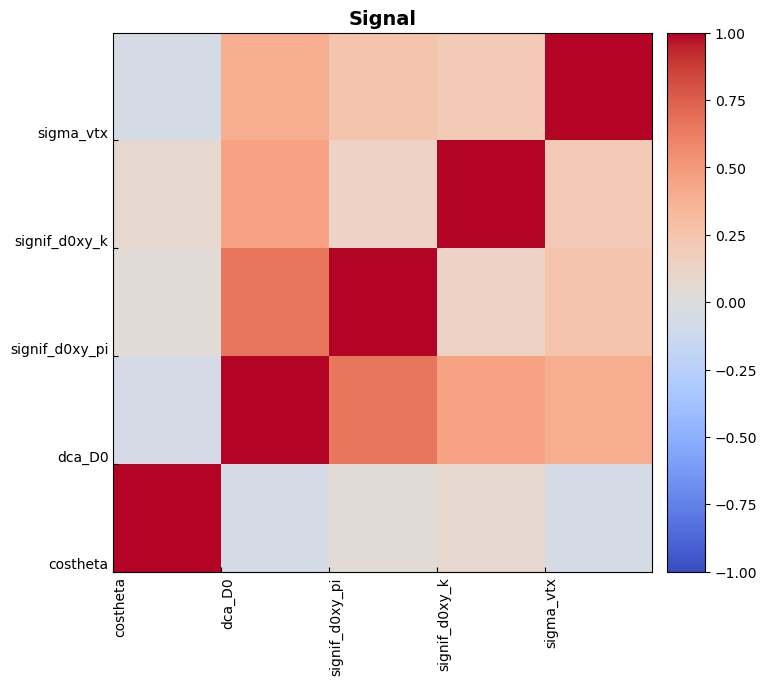

In [406]:
plot_utils.plot_corr([selsig, selsig], features_for_train, leg_labels[1:])
plt.savefig(f'{wdir}/ML/features/correlation_plot_sig.png', bbox_inches='tight')
plt.show()
plt.close()  

## BDT Training

In [407]:
# Initiate BDT model
model_clf = xgb.XGBClassifier(verbosity=1)
model_hdl = ModelHandler(model_clf, features_for_train)
print("Features used for training:", model_hdl.get_training_columns())

Features used for training: ['costheta', 'dca_D0', 'signif_d0xy_pi', 'signif_d0xy_k', 'sigma_vtx']


In [312]:
# Find optimal hyperparameters with Optuna
hyper_pars_ranges = {'n_estimators': (100, 500),    # default = 100
                     'max_depth': (1, 3),           # default = 6
                     'learning_rate': (0.01, 0.1),  # default = 0.3
                     'min_child_weight': (1, 10),   # default = 1
                     'gamma': (0, 5)                # default = 0
                    }
study = model_hdl.optimize_params_optuna(train_test_data, hyper_pars_ranges, cross_val_scoring='roc_auc', timeout=120, n_jobs=-1, n_trials=100, direction='maximize')

[I 2026-04-06 21:05:14,639] A new study created in memory with name: no-name-8006a0ac-a6ac-4a10-8fb0-74f132cda75b
/home/cy7423/myenvs/hipe4ml/lib/python3.10/site-packages/hipe4ml/model_handler.py:389: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  params[key] = trial.suggest_uniform(
/home/cy7423/myenvs/hipe4ml/lib/python3.10/site-packages/hipe4ml/model_handler.py:389: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  params[key] = trial.suggest_uniform(
/home/cy7423/myenvs/hipe4ml/lib/python3.10/site-packages/hipe4ml/model_handler.py:389: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_f

Number of finished trials: 100
Best trial:
Value: 0.8603144826001147
Params: 
    n_estimators: 315
    max_depth: 3
    learning_rate: 0.08250996823440628
    min_child_weight: 8
    gamma: 2


In [409]:
# Train the model
model_hdl.train_test_model(train_test_data)

y_pred_train = model_hdl.predict(train_test_data[0], False)
y_pred_test = model_hdl.predict(train_test_data[2], False)
# print("Train data pediction: ",y_pred_train)
# print("Test data pediction: ",y_pred_test)

Training xgboost model for classification
Number of detected classes: 2
Training the model: ...
Training the model: Done!
Testing the model: ...
ROC_AUC_score: 0.843798
Testing the model: Done!


In [39]:
params=model_hdl.get_model_params()
np.save(f'{wdir}/ML/hyperparameters', params)

# params = np.load(f'{wdir}/ML/hyperparameters.npy',allow_pickle=True,encoding='latin1').item()
print('n_estimators:', params['n_estimators'])
print('max_depth:', params['max_depth'])
print('learning_rate:', params['learning_rate'])
print('min_child_weight:', params['min_child_weight'])
print('gamma:', params['gamma'])

n_estimators: 414
max_depth: 3
learning_rate: 0.09832241008914641
min_child_weight: 1
gamma: 0


In [412]:
# save the trained model
model_hdl.model.save_model(f"{wdir}/ML/trained_model_clf.json")

In [413]:
model = model_hdl.get_original_model()

In [414]:
X_train, X_test = train_test_data[0], train_test_data[2]  # training and validation data
y_train, y_test = train_test_data[1], train_test_data[3]  # labels

# signal BDT efficiency as a function of the BDT score
EFFICIENCY, THRESHOLD = analysis_utils.bdt_efficiency_array(y_test, y_pred_test, 10000)
bdt_efficiency_signal = np.column_stack((THRESHOLD, EFFICIENCY))
np.savetxt(f'{wdir}/ML/bdt_efficiency_signal_vs_threshold.txt', bdt_efficiency_signal, header="Threshold Efficiency", fmt='%.6f')

# background BDT efficiency for BACKGROUND as a function of the BDT score
EFFICIENCY_BG, THRESHOLD_BG = analysis_utils.bdt_efficiency_array(1 - y_test, y_pred_test, 10000)
bdt_efficiency_bkg = np.column_stack((THRESHOLD_BG, EFFICIENCY_BG))
np.savetxt(f'{wdir}/ML/bdt_efficiency_bkg_vs_threshold.txt', bdt_efficiency_bkg, header="Threshold Efficiency", fmt='%.6f')

### Results

In [416]:
X_train, X_test = train_test_data[0], train_test_data[2]  # training and validation data
y_train, y_test = train_test_data[1], train_test_data[3]  # labels

y_pred_train = model_hdl.predict(X_train, False)
y_pred_test = model_hdl.predict(X_test, False)

#### Top distributions after ML

In [417]:
for bdt_score in np.arange(0.5,1.0,step=0.1):
    probs_train = model.predict_proba(X_train[model.feature_names_in_])
    is_sig_train = (probs_train[:,1] > bdt_score)
    sig_train = X_train[is_sig_train]
    bkg_train = X_train[~is_sig_train]
    
    leg_labels_train = ['Background', 'Signal', f'BDT>{bdt_score:.1f} train']
    plot_utils.plot_distr([selbkg.get_data_frame(), selsig.get_data_frame(), sig_train],
                          features_for_train, bins=100, labels=leg_labels_train,
                          log=True, density=True, figsize=(12, 7), alpha=0.3, grid=False)
    plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
    plt.figtext(0.15, 0.92, f'{ymin:.1f} < y < {ymax:.1f}')
    plt.figtext(0.15, 0.88, f'{ptmin:.1f} < pT < {ptmax:.1f}')
    plt.savefig(f'{wdir}/ML/sig_bkg_train_distributions_plot_BDT_{bdt_score:.1f}.png')
    plt.close()
    
    probs_test = model.predict_proba(X_test[model.feature_names_in_])
    is_sig_test = (probs_test[:,1] > bdt_score)
    sig_test = X_test[is_sig_test]
    bkg_test = X_test[~is_sig_test]
    
    leg_labels_test = ['Background', 'Signal', f'BDT>{bdt_score:.1f} test']
    plot_utils.plot_distr([selbkg.get_data_frame(), selsig.get_data_frame(), sig_test],
                          features_for_train, bins=100, labels=leg_labels_test,
                          log=True, density=True, figsize=(12, 7), alpha=0.3, grid=False)
    plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
    plt.figtext(0.15, 0.92, f'{ymin:.1f} < y < {ymax:.1f}')
    plt.figtext(0.15, 0.88, f'{ptmin:.1f} < pT < {ptmax:.1f}')
    plt.savefig(f'{wdir}/ML/sig_bkg_test_distributions_plot_BDT_{bdt_score:.1f}.png')
    plt.close()
    

In [418]:
probs = model.predict_proba(X_train[model.feature_names_in_])
threshold = 0.8
is_sig = (probs[:,1] > threshold)
sig_ml = X_train[is_sig]
bkg_ml = X_train[~is_sig]

print(f'Total number of sig and bkg: {len(X_train)}')
print(f'Number of sig selected with ml: {len(sig_ml)}')

Total number of sig and bkg: 26724
Number of sig selected with ml: 5993


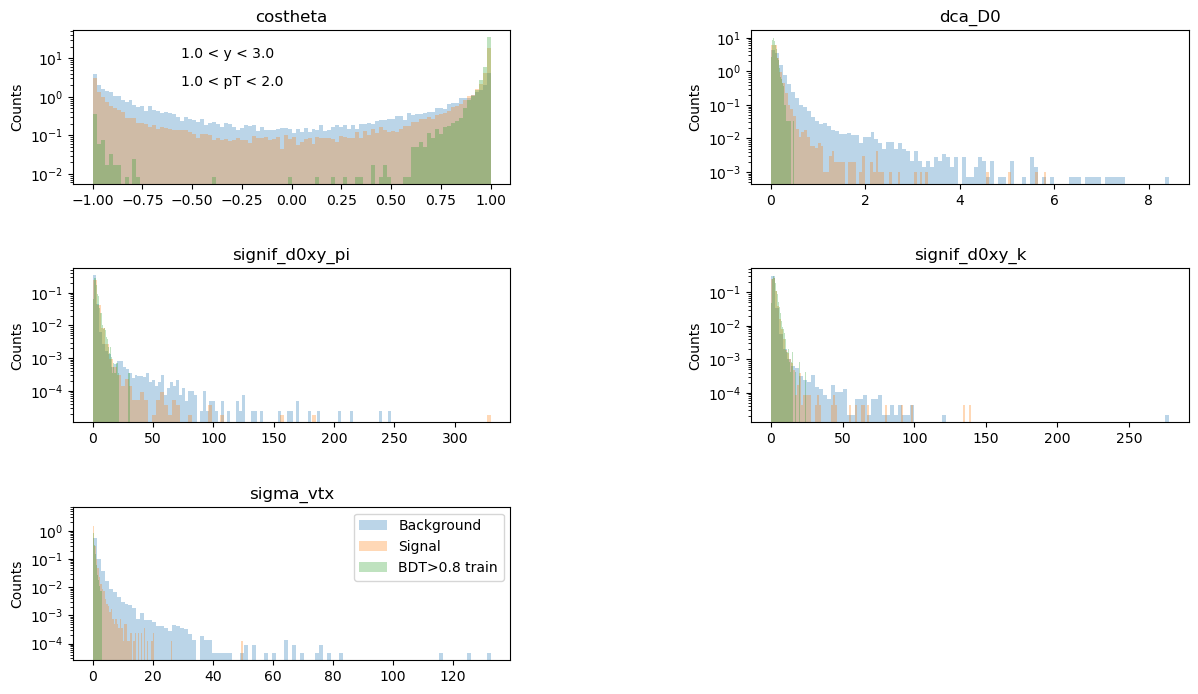

In [419]:
leg_labels = ['Background', 'Signal', f'BDT>{threshold} train']
plot_utils.plot_distr([selbkg.get_data_frame(), selsig.get_data_frame(), sig_ml], features_for_train, bins=100, labels=leg_labels, log=True, density=True, figsize=(12, 7), alpha=0.3, grid=False)
plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
plt.figtext(0.15, 0.92, f'{ymin:.1f} < y < {ymax:.1f}')
plt.figtext(0.15, 0.88, f'{ptmin:.1f} < pT < {ptmax:.1f}')
# plt.savefig(f'{wdir}/ML/sig_bkg_train_distributions_plot_BDT_{threshold}.png') 
plt.show()
plt.close() 

#### ML training results

In [420]:
# Extract results from Optuna study
trials_data = []
for trial in study.trials:
    trials_data.append({
        "trial": trial.number,
        "n_estimators": trial.params["n_estimators"],
        "max_depth": trial.params["max_depth"],
        "learning_rate": trial.params["learning_rate"],
        "value": trial.value  # target
    })

df = pd.DataFrame(trials_data)

In [421]:
leg_labels = ['Background', 'Signal']
ml_out_fig = plot_utils.plot_output_train_test(model_hdl, train_test_data, 100, 
                                               False, leg_labels, True, density=True)
plt.title(f'{ymin:.1f} < y < {ymax:.1f}, {ptmin:.1f} < pT < {ptmax:.1f}')

roc_train_test_fig = plot_utils.plot_roc_train_test(y_test, y_pred_test,
                                                    y_train, y_pred_train, None, leg_labels)
plt.title(f'{ymin:.1f} < y < {ymax:.1f}, {ptmin:.1f} < pT < {ptmax:.1f}')

ml_out_fig.savefig(f'{wdir}/ML/train_test.png')
roc_train_test_fig.savefig(f'{wdir}/ML/roc_train_test.png')

In [422]:
# plot_utils.plot_learning_curves(model_hdl,train_test_data,100)
# plt.show()
# plt.savefig(f'{wdir}/ML/learning_curves.png')
# plt.close()  

In [423]:
# Create ROC using libraries
fpr, tpr, thresholds = roc_curve(train_test_data[1], y_pred_train) #ytrain and y_pred_train 

# print(thresholds)

# Compute AUC
auc = roc_auc_score(train_test_data[1], y_pred_train)
print(f"ROC AUC: {auc:.2f}")


ROC AUC: 0.87


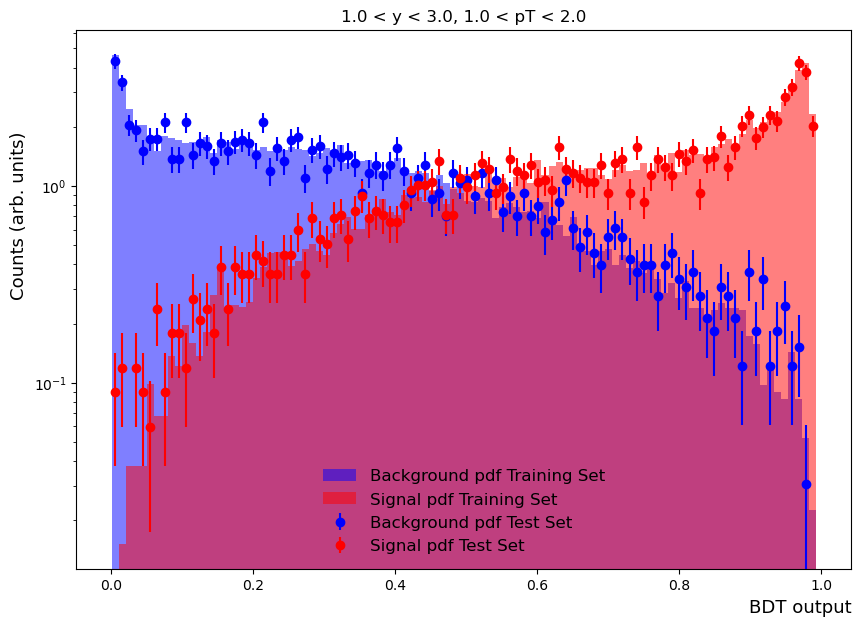

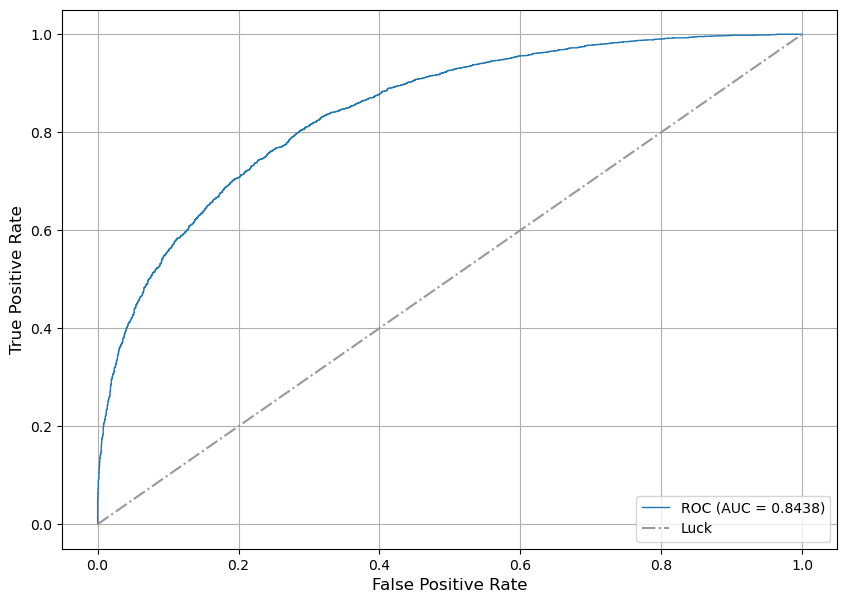

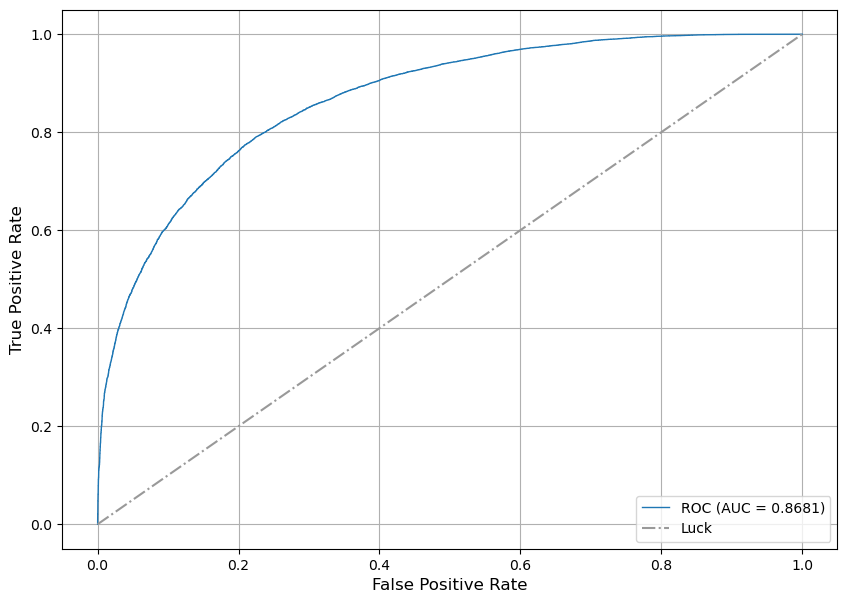

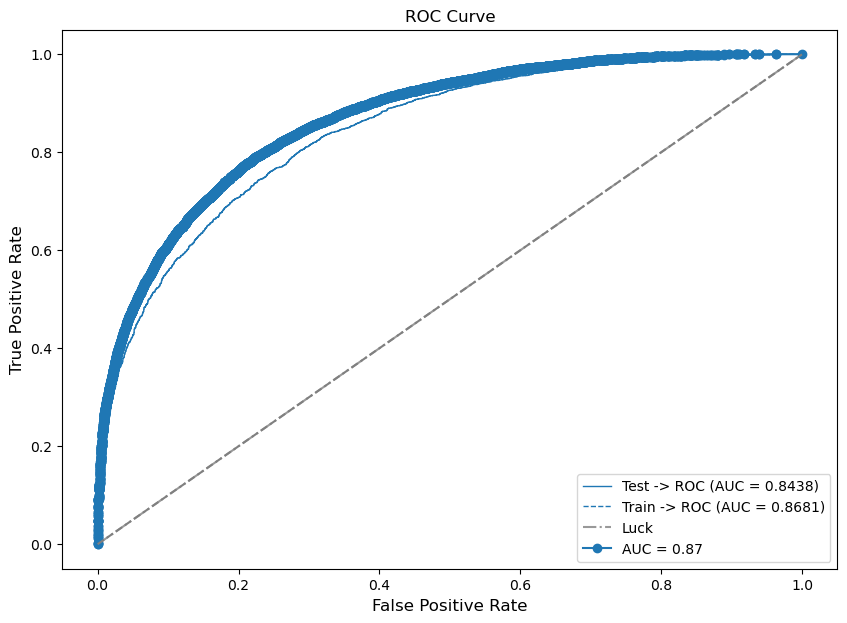

In [424]:
# Plot ROC Curve
plt.plot(fpr, tpr, marker='o', label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line (random)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()
plt.savefig(f'{wdir}/ML/ROC_AUC_library.png')
plt.close()

In [425]:
# Ensure train_test_data[0] and train_test_data[2] are DataFrames and match model expectations
X_train, X_test = train_test_data[0], train_test_data[2]  # training and validation data
y_train, y_test = train_test_data[1], train_test_data[3]  # labels

In [426]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, (y_pred_test > 0.5).astype(int))

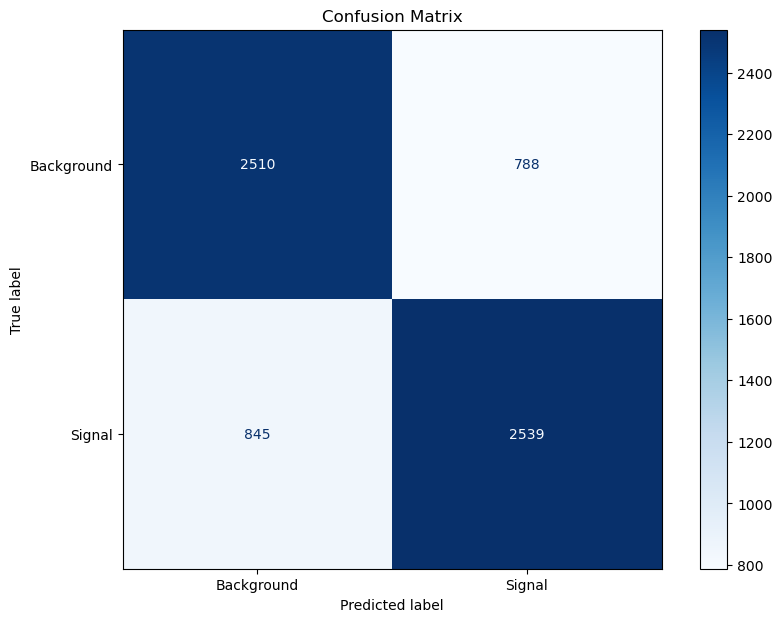

In [427]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=leg_labels)
disp.plot(cmap='Blues')
plt.rcParams["figure.figsize"] = (10, 7)
plt.title('Confusion Matrix')
plt.show()
plt.savefig(f'{wdir}/ML/confusion_matrix.png')
plt.close()

In [428]:
feature_names = X_test.columns.tolist()  # Extracts column names from DataFrame

In [429]:
# Compute log loss manually (how well model correctly classifies events, with 0 being ideal)
train_logloss = log_loss(y_train, y_pred_train)
test_logloss = log_loss(y_test, y_pred_test)
print(f"Computed Training Log Loss: {train_logloss:.5f}")
print(f"Computed Validation Log Loss: {test_logloss:.5f}")

Computed Training Log Loss: 0.45192
Computed Validation Log Loss: 0.48636


#### SHAP

In [430]:
os.makedirs(f'{wdir}/ML/SHAP', exist_ok=True)

In [431]:
model = model_hdl.get_original_model()
explainer = shap.TreeExplainer(model)

In [432]:
X_train, X_test = train_test_data[0], train_test_data[2]  # training and validation data
y_train, y_test = train_test_data[1], train_test_data[3]  # labels

# Shap is evaluated for selected feature for ML
X_train_sel = X_train[model.feature_names_in_]
X_test_sel = X_test[model.feature_names_in_]
y_train_sel = y_train[:len(X_train_sel)]  
y_test_sel = y_test[:len(X_test_sel)] 

In [433]:
X_train_sel

,costheta,dca_D0,signif_d0xy_pi,signif_d0xy_k,sigma_vtx
338193,-0.995992,0.115320,0.492908,2.040095,0.234996
71131,0.993426,0.025993,1.032668,0.570986,0.207669
169784,0.999955,0.002404,0.476539,0.591489,0.271911
340765,0.961632,0.279402,2.539928,1.501891,0.140036
7903,0.972753,0.175463,2.198992,3.366360,0.297476
...,...,...,...,...,...
71870,-0.221384,0.078104,0.997811,1.833614,0.019792
100423,0.025801,0.076721,1.560610,0.470248,0.182468
288309,0.941159,0.030330,0.823316,0.853113,0.097741
184981,0.976242,0.038386,2.002486,1.396799,0.128765


In [434]:
print("X_train shape:", X_train_sel.shape)
print("X_test shape:", X_test_sel.shape)
print("Model input shape: \n", model.feature_importances_.shape)

X_train shape: (26724, 5)
X_test shape: (6682, 5)
Model input shape: 
 (5,)


In [435]:
shap_values = explainer.shap_values(X_test_sel)
shap_values_array = np.array(shap_values)  # Convert to NumPy array
print("Array Size, nfeatures, nclasses", shap_values_array.shape)  # Should be (6, len(X_test), 2)

Array Size, nfeatures, nclasses (6682, 5)


In [436]:
base_prob= np.mean(model.predict(X_test_sel))  # Mean probability of class 1
print(f"Model Prediction from X_test (Mean): {base_prob} \t Base Value from SHAP: {explainer.expected_value}")


Model Prediction from X_test (Mean): 0.4979048189164921 	 Base Value from SHAP: -0.007535348646342754


In [437]:
base_prob= np.mean(model.predict_proba(X_test_sel)[:, 1])  # Mean probability of class 1
print(f"Model Prediction from X_test (Mean probability): {base_prob} \t Base probability Value from SHAP = {1 / (1 + np.exp(-explainer.expected_value))}")

Model Prediction from X_test (Mean probability): 0.502399742603302 	 Base probability Value from SHAP = 0.49811616713970813


In [438]:
# Print SHAP values for the first 3 test samples
print("SHAP \n",shap_values, "\n Length", len(shap_values))
print("Test",X_test_sel, "\n Length", len(X_test_sel))
# Print SHAP values and corresponding predictions
for i in range(10):  # Analyze the first 3 test samples
    print(f"\n--- Test Sample {i} ---")
    print("X_test: \n", X_test_sel.iloc[i])
    print("y_test:", y_test_sel[i])
    print("SHAP Values:", shap_values[i])
    print("SHAP Sum:", shap_values[i].sum())
    print("Base Value:", explainer.expected_value)
    print("Actual Prediction:", model.predict(X_test_sel.iloc[i].values.reshape(1, -1))[0]) 
    print("SHAP Predicted Value:", explainer.expected_value + shap_values[i].sum())
    print("Predicted Probabilties:", model.predict_proba(X_test_sel.iloc[i].values.reshape(1, -1))[0]) 
     # Compute P(class 1) from SHAP predicted value using the sigmoid function
    shap_pred_prob = 1 / (1 + np.exp(-(explainer.expected_value + shap_values[i].sum())))
    print(f"SHAP Computed Probability: 1./[1+exp(-SHAP Predicted Value)] Background = {1.0-shap_pred_prob}, Signal = {shap_pred_prob}")


SHAP 
 [[-0.63034844 -0.52932864 -0.24623863  1.1961639  -0.32931972]
 [ 0.9462509   0.65863425 -0.2887538  -0.16839762  0.44722608]
 [ 0.29027668 -0.888891   -0.3839001   0.10704871 -0.23527773]
 ...
 [-0.7535795  -0.612618    0.9428814  -0.4002629  -0.2033516 ]
 [ 0.01259251  0.6108123   0.02362386 -0.5540561  -0.20390905]
 [ 0.21707028  0.7054942  -0.17106241 -0.05898141  0.86742914]] 
 Length 6682
Test         costheta    dca_D0  signif_d0xy_pi  signif_d0xy_k  sigma_vtx
31301  -0.539467  0.210375        1.049519       3.579723   0.715381
25827   0.991563  0.040252        1.196661       1.330414   0.143557
120338  0.947998  0.233304        1.189449       1.696295   0.580862
27208   0.917842  0.159439        0.846704       1.758891   0.392884
110547  0.991173  0.090065        2.640137       3.111552   0.174629
...          ...       ...             ...            ...        ...
66357   0.819665  0.169558        0.806840       0.407715   2.413783
141991 -0.694791  0.317758        0.84

In [439]:
# Compute SHAP values for a single sample (X_test_sel must have exactly 1 row)
shap_values_sel = explainer.shap_values(X_test_sel.iloc[[0]])  # Note the double brackets to keep DataFrame format

In [440]:
# Use the result directly
shap_vals_sample = shap_values_sel[0]  # First and only row
#features_sample = X_test_sel.iloc[0].round(4) limit to 4 features
features_sample = X_test_sel.iloc[0].apply(lambda x: round(x, 2) if isinstance(x, (float, np.floating)) else x) # round decimals

In [441]:
# Confirm shape match
print("SHAP values length:", len(shap_vals_sample))
print("Feature length:", len(features_sample))

SHAP values length: 5
Feature length: 5


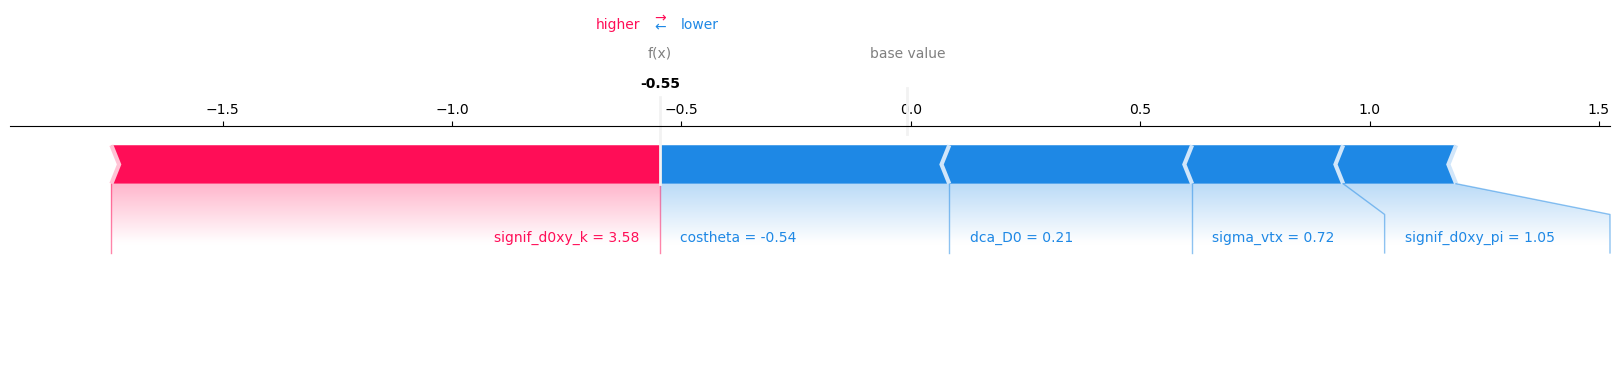

In [442]:
# Generate the force plot
fig = shap.plots.force(
    explainer.expected_value,   
    shap_vals_sample,
    features_sample,
    matplotlib=True,
    show=False
)

fig.set_size_inches(20, 5)  # wider and taller
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.4)  # more space at bottom for labels

for text in fig.findobj(match=plt.Text):
    text.set_fontsize(10)  # or try 12 for better readability

plt.show()
# Save the plot
fig.savefig(f'{wdir}/ML/SHAP/feature_shap_classifier_D0.png', format='png', dpi=200, bbox_inches='tight')

In [443]:
shap_val_array = shap_values_sel[0]  # For the first sample

In [444]:
formatted_labels = pd.Series(
    [f"{v:.2f}" for v in shap_val_array],  # format to 2 decimal places
    index=X_test_sel.columns               # use feature names
)

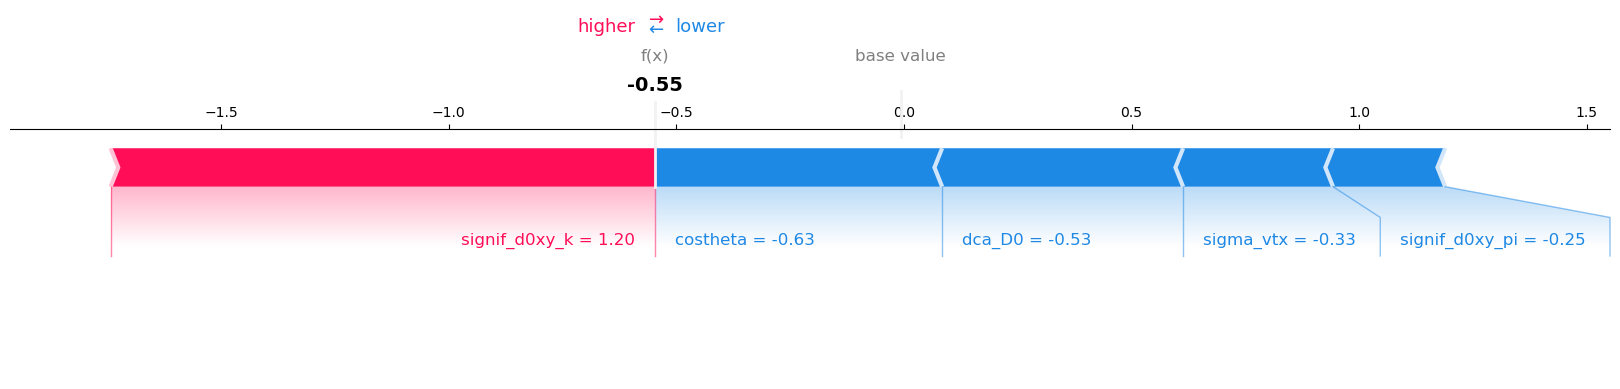

In [445]:
# Plot with string-formatted SHAP values
fig = shap.plots.force(
    explainer.expected_value,
    shap_val_array,
    formatted_labels,         # this will now show 'costheta = 1.6500', etc.
    matplotlib=True,
    show=False
)

# Improve layout and readability
fig.set_size_inches(20, 5)
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.4)

plt.show()
# Save the plot
fig.savefig(f'{wdir}/ML/SHAP/shap_classifier_D0.png', format='png', dpi=200, bbox_inches='tight')

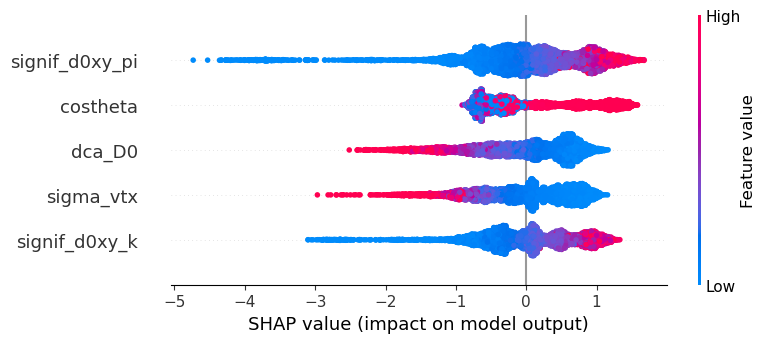

In [446]:
shap.plots.beeswarm(explainer(X_test_sel), show=False)
plt.savefig(f'{wdir}/ML/SHAP/shap_beeswarm.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

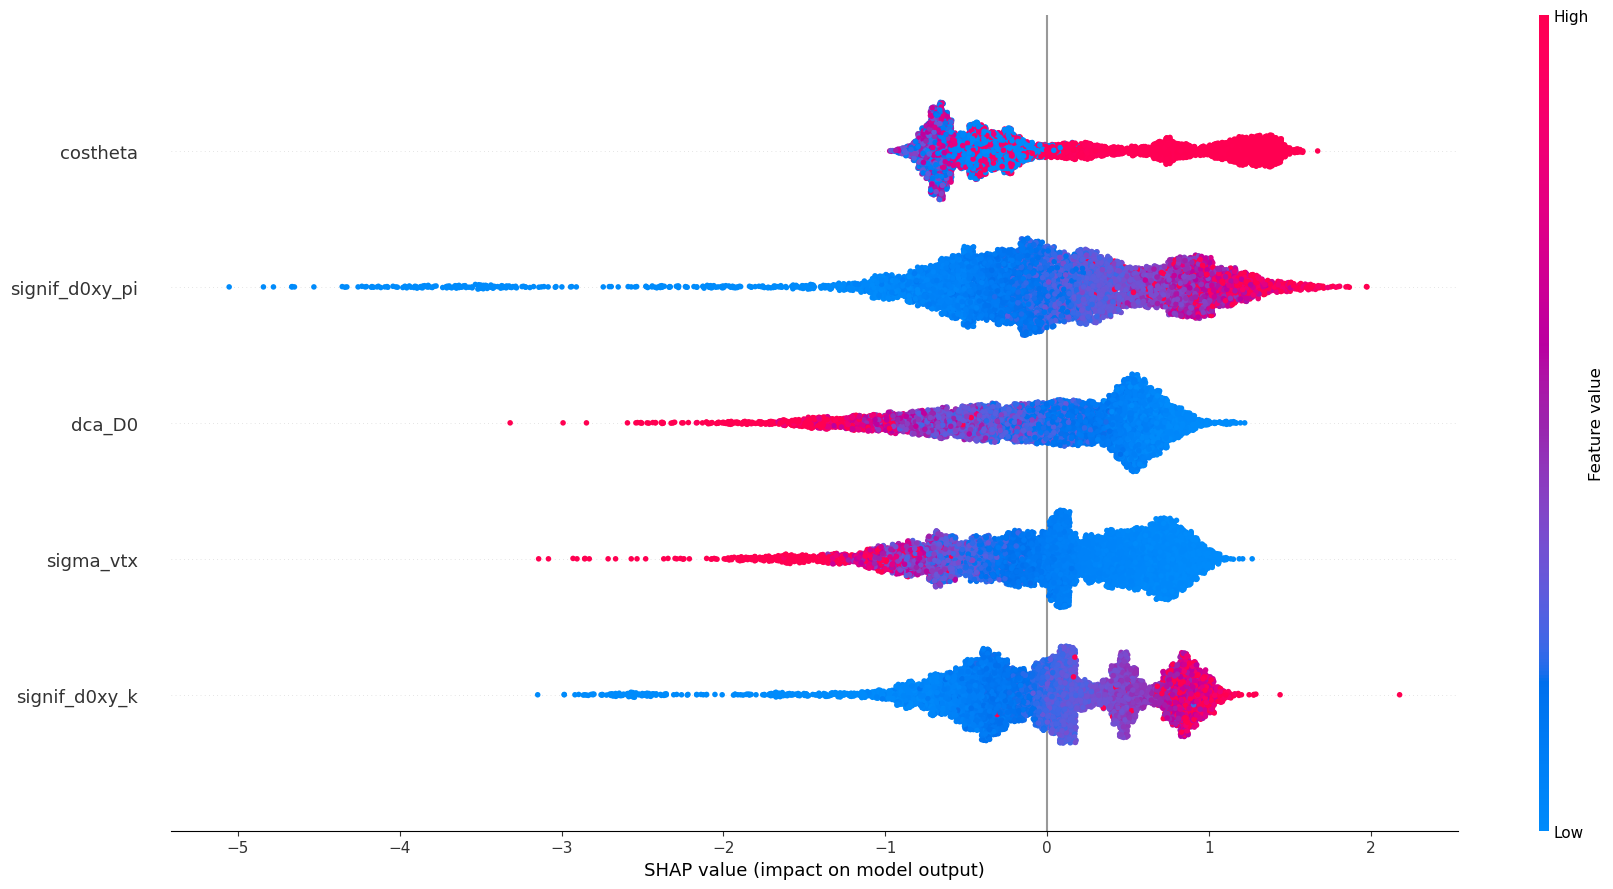

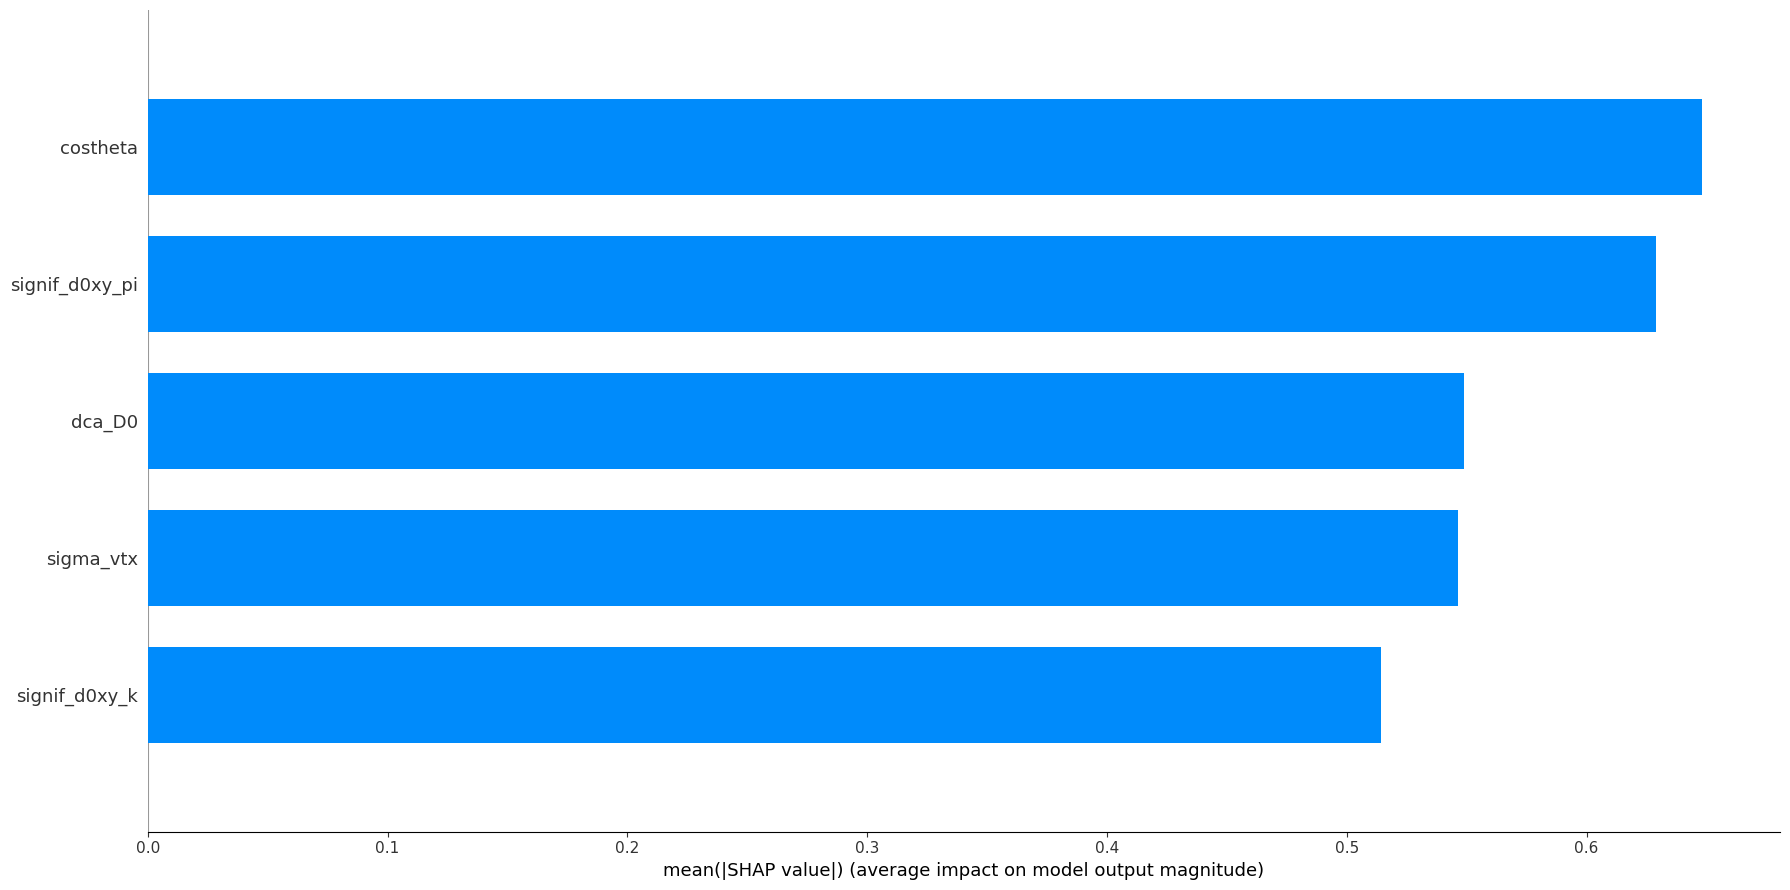

In [447]:
plot_utils.plot_feature_imp(train_test_data[2], train_test_data[3], model_hdl, labels=leg_labels)

# only show the SHAP summary plot
# plt.close(shap_figs[0])
# plt.close(shap_figs[1])
# plt.close(shap_figs[2])
plt.savefig(f'{wdir}/ML/SHAP/shap_feature_impact.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

In [449]:
trees_df = model.get_booster().trees_to_dataframe()

In [450]:
trees_df[trees_df['Tree']==0]

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,costheta,0.950663,0-1,0-2,0-1,3505.660400,6681.00,NaN
1,0,1,0-1,sigma_vtx,0.408345,0-3,0-4,0-3,1136.936400,4674.50,NaN
2,0,2,0-2,sigma_vtx,1.406348,0-5,0-6,0-5,542.300537,2006.50,NaN
3,0,3,0-3,costheta,0.597478,0-7,0-8,0-7,299.946564,2526.00,NaN
4,0,4,0-4,signif_d0xy_pi,0.952876,0-9,0-10,0-9,195.063965,2148.50,NaN
5,0,5,0-5,signif_d0xy_pi,1.149829,0-11,0-12,0-11,276.784180,1776.25,NaN
6,0,6,0-6,dca_D0,0.212944,0-13,0-14,0-13,81.311172,230.25,NaN
7,0,7,0-7,Leaf,NaN,NaN,NaN,NaN,-0.012575,1684.25,NaN
8,0,8,0-8,Leaf,NaN,NaN,NaN,NaN,0.021494,841.75,NaN
9,0,9,0-9,Leaf,NaN,NaN,NaN,NaN,-0.070176,591.00,NaN


In [451]:
print(model_hdl.model.get_booster().get_dump()[0])

0:[costheta<0.950662851] yes=1,no=2,missing=1
	1:[sigma_vtx<0.408344716] yes=3,no=4,missing=3
		3:[costheta<0.59747839] yes=7,no=8,missing=7
			7:leaf=-0.0125748506
			8:leaf=0.0214944109
		4:[signif_d0xy_pi<0.952875972] yes=9,no=10,missing=9
			9:leaf=-0.0701761097
			10:leaf=-0.0386535153
	2:[sigma_vtx<1.40634799] yes=5,no=6,missing=5
		5:[signif_d0xy_pi<1.14982891] yes=11,no=12,missing=11
			11:leaf=0.0276404116
			12:leaf=0.070470266
		6:[dca_D0<0.212944001] yes=13,no=14,missing=13
			13:leaf=0.00414799619
			14:leaf=-0.0538666956



<Figure size 2000x1000 with 0 Axes>

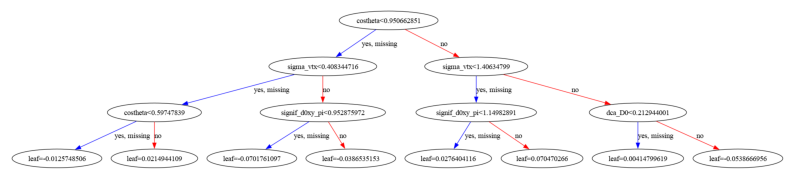

In [452]:
plt.figure(figsize=(20,10))
xgb.plot_tree(model, num_trees=0)
plt.savefig(f'{wdir}/ML/tree.pdf')
plt.show()

#### BDT efficiencies

In [453]:
# get sig and bkg efficiencies
greff_sig = TGraph(f'{wdir}/ML/bdt_efficiency_signal_vs_threshold.txt')
greff_bkg = TGraph(f'{wdir}/ML/bdt_efficiency_bkg_vs_threshold.txt')
bdt_threshold = 0.6

for i in range(greff_sig.GetN()):
    # Retrieve the (x, y) points from the graphs
    if greff_sig.GetPointX(i) > bdt_threshold: break
    bdt_score = greff_sig.GetPointX(i)
    eff_sig = greff_sig.GetPointY(i)
    eff_bkg = greff_bkg.GetPointY(i)

print(f'BDT threshold: {bdt_score}')
print(f'sig efficiency: {eff_sig}')
print(f'bkg efficiency: {eff_bkg}')

BDT threshold: 0.599995
sig efficiency: 0.635343
bkg efficiency: 0.149181


In [454]:
BDT_EFFICIENCY_PLOT = plot_utils.plot_bdt_eff(THRESHOLD, EFFICIENCY)
BDT_EFFICIENCY_PLOT.savefig(f'{wdir}/ML/bdt_efficiency_sig.png')

BDT_EFFICIENCY_PLOT_BG = plot_utils.plot_bdt_eff(THRESHOLD_BG, EFFICIENCY_BG)
BDT_EFFICIENCY_PLOT_BG.savefig(f'{wdir}/ML/bdt_efficiency_bkg.png')

In [455]:
# Calculate BACKGROUND REJECTION
REJECTION_BG = 1 - EFFICIENCY_BG

# Plot BACKGROUND REJECTION
BDT_REJECTION_PLOT_BG = plot_utils.plot_bdt_eff(THRESHOLD_BG, REJECTION_BG)
BDT_REJECTION_PLOT_BG.savefig(f'{wdir}/ML/bdt_rejection_background.png')

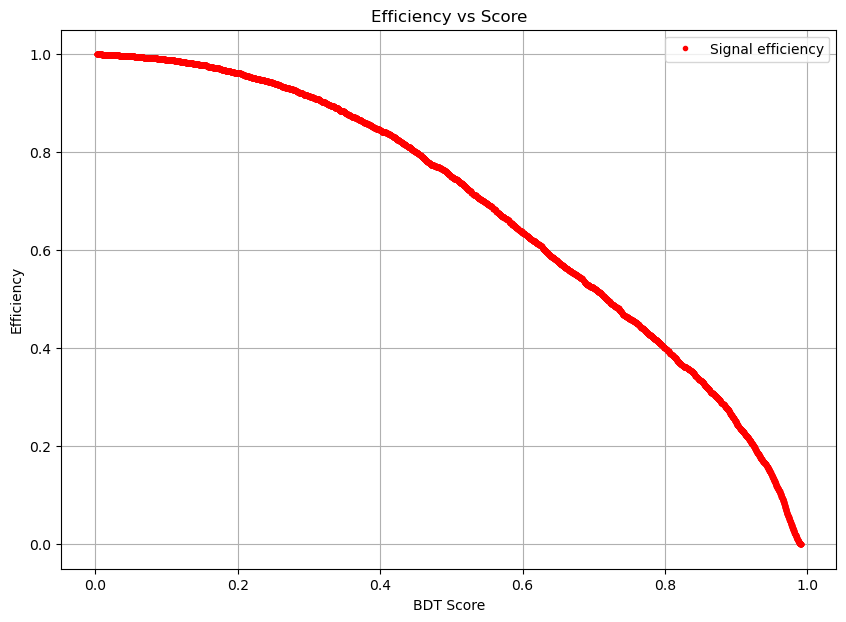

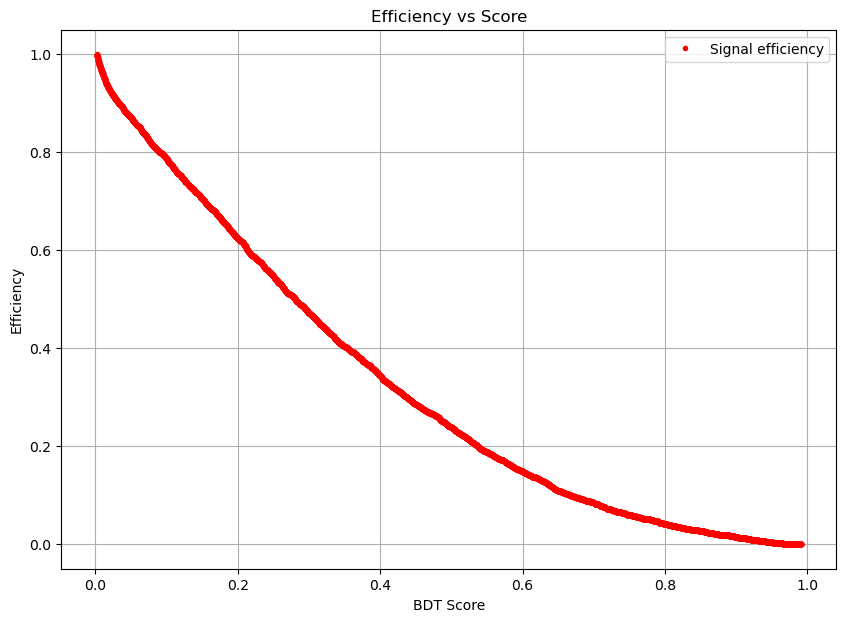

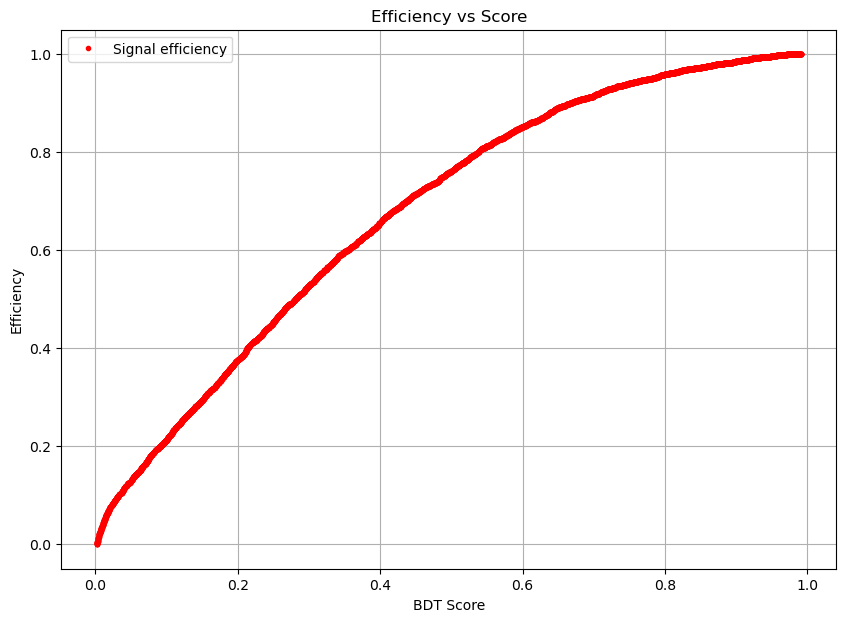

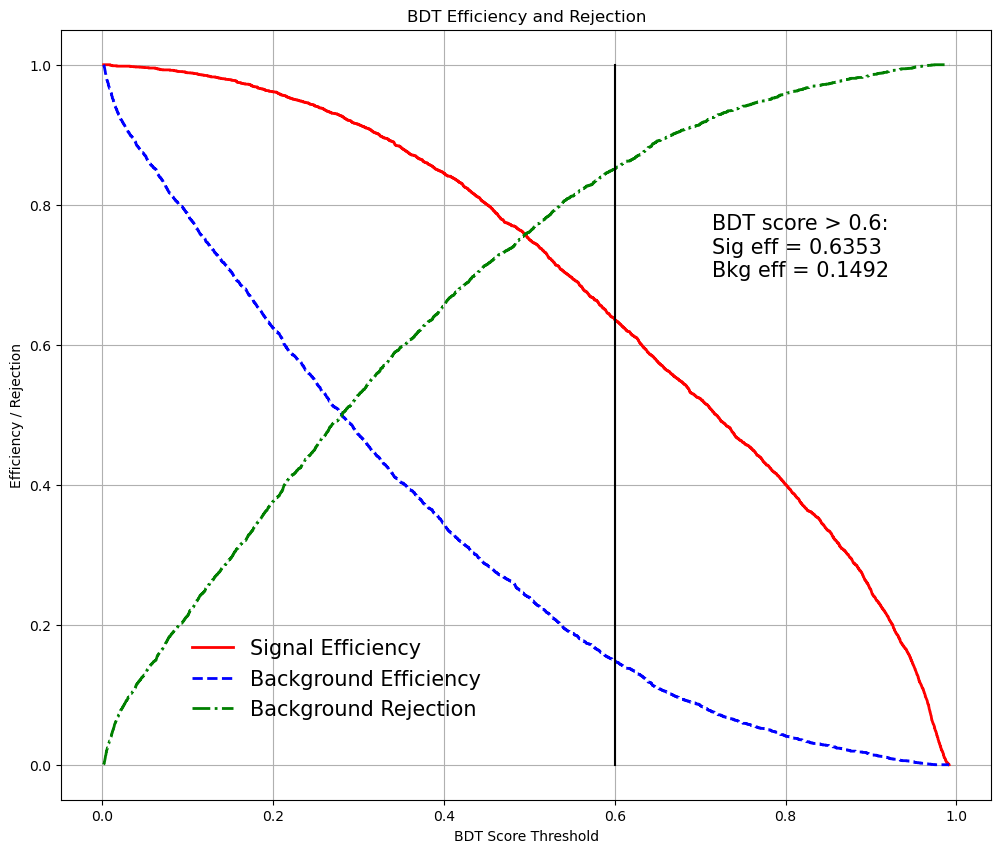

In [456]:
#Superimposed
plt.figure(figsize=(12, 10))
plt.plot(THRESHOLD, EFFICIENCY, label='Signal Efficiency', color='red', linewidth=2)
plt.plot(THRESHOLD_BG, EFFICIENCY_BG, label='Background Efficiency', color='blue', linestyle='--', linewidth=2)
plt.plot(THRESHOLD_BG, REJECTION_BG, label='Background Rejection', color='green', linestyle='-.', linewidth=2)

plt.xlabel('BDT Score Threshold')
plt.ylabel('Efficiency / Rejection')
plt.title('BDT Efficiency and Rejection')
plt.legend(loc='lower left', bbox_to_anchor=(0.12, 0.08), fontsize=15, frameon=False)
plt.grid(True)

text = f'BDT score > {bdt_threshold}: \nSig eff = {eff_sig:.4f} \nBkg eff = {eff_bkg:.4f}'
plt.text(0.7, 0.68, text, transform=plt.gca().transAxes, fontsize=15)

# vertical line
y = np.linspace(0, 1, 100)
x = np.full(len(y), bdt_threshold)
plt.plot(x, y, color='black')

plt.savefig(f'{wdir}/ML/bdt_eff_rej_superimposed.png')
plt.show()
plt.close()

# D0 inv mass after ML

Compare invariant mass plots before and after ML.

In [50]:
ymin = 1
ymax = 3
ptmin = 1
ptmax = 2

In [51]:
# yslices = [[-1,1], [1,3]]
# ptslices = [[0,1], [1,2], [2,3]]

# ymin = yslices[0][0]
# ymax = yslices[0][1]
# ptmin = ptslices[1][0]
# ptmax = ptslices[1][1]

In [52]:
print(f'ymin: {ymin} \nymax: {ymax} \nptmin: {ptmin} \nptmax: {ptmax}')

ymin: 1 
ymax: 3 
ptmin: 1 
ptmax: 2


In [53]:
wdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}'

In [54]:
# location of ML results
ml_dir = f'{wdir}/ML'

In [55]:
# locations to store data after ML
sigdir_ml = f'{wdir}/data_after_ML/sig_data'
bkgdir_ml = f'{wdir}/data_after_ML/bkg_data'

os.makedirs(sigdir_ml, exist_ok=True)
os.makedirs(bkgdir_ml, exist_ok=True)

In [56]:
# locations of prepared sig and bkg data
sigdir = f'{wdir}/data_before_ML/sig_data'
bkgdir = f'{wdir}/data_before_ML/bkg_data'

# locations of total sig and bkg data
sigtot_dir = f'/home/cy7423/eic/ML_by_slices/ML_all_features/data_before_ML/sig_data'
bkgtot_dir = f'/home/cy7423/eic/ML_by_slices/ML_all_features/data_before_ML/bkg_data'

In [57]:
# locations of root files from analysis of D0 and DIS samples
samples_D0 = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_D0_10x100_minQ2_1_25.10.3'
samples_DIS = '/home/cy7423/eic/ML_by_slices/analysis_jobs/output_DIS_10x100_minQ2_1_25.10.0'

In [58]:
# locations of root files from analysis of D0 and DIS samples
D0_dir = samples_D0
DIS_dir = samples_DIS

In [59]:
fsig_slice = get_data_for_y_pt_slice(sigdir, sigtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Signal')
fbkg_slice = get_data_for_y_pt_slice(bkgdir, bkgtot_dir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Bkg')

## Resample data

In [62]:
# get resampled data before ML
sig_stats = np.load(f'{sigdir}/signal_sampling_stats_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_before_ml.npy', allow_pickle=True, encoding='latin1').item()
bkg_stats = np.load(f'{bkgdir}/bkg_sampling_stats_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_before_ml.npy', allow_pickle=True, encoding='latin1').item()

nsig = sig_stats['expected_sig_candidates']
nbkg = bkg_stats['expected_bkg_candidates']
print(f'sig/bkg candidates before ML: {nsig} / {nbkg} = {nsig/nbkg:.4f}')

sig/bkg candidates before ML: 216346 / 32515822 = 0.0067


## Optimize BDT cut

In [63]:
# get sig and bkg efficiencies
greff_sig = TGraph(f'{ml_dir}/bdt_efficiency_signal_vs_threshold.txt')
greff_bkg = TGraph(f'{ml_dir}/bdt_efficiency_bkg_vs_threshold.txt')

In [64]:
results = {
    'Sig eff': {},
    'Bkg eff': {},
    'S/B': {},
    'Signif': {}
}
for bdt_threshold in np.arange(0.5, 1, step=0.1):
    for i in range(greff_sig.GetN()):
    # Retrieve the (x, y) points from the graphs
        if greff_sig.GetPointX(i) > bdt_threshold: break
        bdt_score = greff_sig.GetPointX(i)
        eff_sig = greff_sig.GetPointY(i)
        eff_bkg = greff_bkg.GetPointY(i)

    results['Sig eff'][f'{bdt_score:.1f}'] = eff_sig
    results['Bkg eff'][f'{bdt_score:.1f}'] = eff_bkg
    
    print(f'BDT threshold: {bdt_score:.1f}')
    print(f'sig efficiency: {eff_sig}')
    print(f'bkg efficiency: {eff_bkg}')
    print()
    
    # apply BDT cut to data
    nsig_ml = int(nsig * eff_sig)
    nbkg_ml = int(nbkg * eff_bkg)
    
    fsig_resamp_ml = get_resampled_signal(sigdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                          nExpected_D0=nsig_ml, ml=f'bdt_{bdt_score:.1f}')
    fbkg_resamp_ml = get_resampled_bkg(bkgdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                       nExpected_bkg=nbkg_ml, ml=f'bdt_{bdt_score:.1f}')
    
    s_over_b_ml, signif_ml = calculate_s_over_b_and_signif(f'{wdir}/data_after_ML', fsig_resamp_ml, fbkg_resamp_ml,
                                                          ymin, ymax, ptmin, ptmax, ml=f'bdt_{bdt_score:.1f}')
    print('----------------------------------------------------------')
    results['S/B'][f'{bdt_score:.1f}'] = s_over_b_ml
    results['Signif'][f'{bdt_score:.1f}'] = signif_ml
    
results_df = pd.DataFrame(results)
np.save(f'{wdir}/sig_vs_bkg_stats_after_ml_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}', results)

BDT threshold: 0.5
sig efficiency: 0.764775
bkg efficiency: 0.211643

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.1520
Signif = 137.6788
----------------------------------------------------------
BDT threshold: 0.6
sig efficiency: 0.679965
bkg efficiency: 0.140085

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.1983
Signif = 144.0610
----------------------------------------------------------
BDT threshold: 0.7
sig efficiency: 0.5724
bkg efficiency: 0.082777

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.2628
Signif = 148.3569
----------------------------------------------------------
BDT threshold: 0.8
sig efficiency: 0.439421
bkg efficiency: 0.039418

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.4302
Signif = 155.8838
----------------------------------------------------------
BDT threshold: 0.9
sig efficiency: 0.269208
bkg efficiency: 0.013341

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.9388
Signif = 155.4401
------------------------------------

In [65]:
bdt_opt = np.load(f'{wdir}/sig_vs_bkg_stats_after_ml_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}.npy',allow_pickle=True,encoding='latin1').item()

In [66]:
pd.DataFrame(bdt_opt)

,Sig eff,Bkg eff,S/B,Signif
0.5,0.764775,0.211643,0.151982,137.678818
0.6,0.679965,0.140085,0.198279,144.060952
0.7,0.572400,0.082777,0.262815,148.356907
0.8,0.439421,0.039418,0.430151,155.883837
0.9,0.269208,0.013341,0.938849,155.440105


In [71]:
bdt_opt2 = np.load(f'/home/cy7423/eic/ML_by_slices/ML_all_features/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}/sig_vs_bkg_stats_after_ml_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}.npy',allow_pickle=True,encoding='latin1').item()

In [72]:
pd.DataFrame(bdt_opt2)

,Sig eff,Bkg eff,S/B,Signif
0.5,0.764775,0.211643,0.151982,137.678818
0.6,0.679965,0.140085,0.198279,144.060952
0.7,0.572400,0.082777,0.262815,148.356907
0.8,0.439421,0.039418,0.430151,155.883837
0.9,0.269208,0.013341,0.938849,155.440105


## Plot inv mass

In [83]:
ymin = 1
ymax = 3
ptmin = 1
ptmax = 2

In [84]:
# yslices = [[-1,1], [1,3]]
# ptslices = [[0,1], [1,2], [2,3]]

# ymin = yslices[0][0]
# ymax = yslices[0][1]
# ptmin = ptslices[1][0]
# ptmax = ptslices[1][1]

In [85]:
print(f'ymin: {ymin} \nymax: {ymax} \nptmin: {ptmin} \nptmax: {ptmax}')

ymin: 1 
ymax: 3 
ptmin: 1 
ptmax: 2


In [86]:
wdir = f'{homedir}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}'

In [87]:
# locations of sig and bkg data before ML
sigdir = f'{wdir}/data_before_ML/sig_data'
bkgdir = f'{wdir}/data_before_ML/bkg_data'
sigdir_ml = f'{wdir}/data_after_ML/sig_data'
bkgdir_ml = f'{wdir}/data_after_ML/bkg_data'

fsig_slice = get_data_for_y_pt_slice(sigdir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Signal')
fbkg_slice = get_data_for_y_pt_slice(bkgdir, y_pt_lim=[[ymin,ymax],[ptmin,ptmax]], filt='Bkg')

In [88]:
# resampled data before ML
fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')
fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')

hsig = fsig_resamp.Get('hData_D0')
hbkg = fbkg_resamp.Get('hData_D0')

print(f'Resampled sig/bkg candidates before ML: {hsig.GetEntries()} / {hbkg.GetEntries()} = {hsig.GetEntries()/hbkg.GetEntries():.4f}')

Resampled sig/bkg candidates before ML: 216346.0 / 32515822.0 = 0.0067


In [89]:
s_over_b, signif = calculate_s_over_b_and_signif(f'{wdir}/data_before_ML', fsig_resamp, fbkg_resamp,
                                                ymin, ymax, ptmin, ptmax)

Signal peak range: 1.8189 < mass_D0 < 1.9129
S/B = 0.0423
Signif = 86.5146


In [80]:
hists = {'h': [],
         'hml': []
        }
legends = []
texts = []
cnt = 0
for bdt_score in np.arange(0.5,1.0,step=0.1):
    cnt += 1
    # get resampled data after ML
    fsig_resamp_ml = get_resampled_signal(sigdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                          ml=f'bdt_{bdt_score:.1f}')
    fbkg_resamp_ml = get_resampled_bkg(bkgdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'bdt_{bdt_score:.1f}')
    # get stats
    stats = np.load(f'{wdir}/data_after_ML/s_over_b_and_signif_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.npy', allow_pickle=True, encoding='latin1').item()
    s_over_b_ml = stats['s_over_b']
    signif_ml = stats['signif']
    
    h = hsig.Clone(f'hsig_{cnt}')
    h.Add(hbkg)
    h.SetDirectory(0)
    hists['h'].append(h)
    
    hsig_ml = fsig_resamp_ml.Get('hData_D0')
    hbkg_ml = fbkg_resamp_ml.Get('hData_D0')
    hml = hsig_ml.Clone(f'hsig_ml_{cnt}')
    hml.Add(hbkg_ml)
    hml.SetDirectory(0)
    hists['hml'].append(hml)
    
    # legend
    l = TLegend(0.6, 0.75, 0.87, 0.85)
    # l = TLegend(0.45, 0.6, 0.8, 0.7)
    l.AddEntry(h, 'no top. cuts')
    l.AddEntry(hml, 'after top. cuts')
    l.SetTextSize(0.03)
    l.SetBorderSize(0)
    legends.append(l)

    # text
    t = TPaveText(0.6, 0.45, 0.87, 0.75, "NDC")
    # t = TPaveText(0.45, 0.2, 0.8, 0.45, "NDC")
    t.SetFillColor(0)
    t.SetBorderSize(0)
    t.SetTextFont(42)
    t.SetTextSize(0.03)
    t.SetTextAlign(13)
    t.AddText(f"no top. cuts:")
    t.AddText(f"S/B = {s_over_b:.2f}")
    t.AddText(f"Signif = {signif:.0f}")
    t.AddText('')
    t.AddText("after top. cuts")
    t.AddText(f"(BDT score > {bdt_score:.1f}):")
    t.AddText(f"S/B = {s_over_b_ml:.2f}")
    t.AddText(f"Signif = {signif_ml:.0f}")
    texts.append(t)


In [81]:
c = TCanvas()
c.Divide(3,2)

cnt = 0
for bdt_score in np.arange(0.5,1.0,step=0.1):
    
    h = hists['h'][cnt]
    hml = hists['hml'][cnt]
    
    c.cd(cnt+1)
    # set styles
    h.SetMarkerStyle(21)
    h.SetMarkerSize(0.2)
    h.SetMarkerColor(kBlack)
    h.SetLineColor(kBlack)
    hml.SetMarkerStyle(20)
    hml.SetMarkerSize(0.2)
    hml.SetMarkerColor(kRed)
    hml.SetLineColor(kRed)
    hml.SetStats(0)

    title = f'{ymin} < y < {ymax}, {ptmin} < pT < {ptmax}'
    h.SetTitle(title)
    h.GetXaxis().SetTitleOffset(1)
    h.GetYaxis().SetTitleOffset(1.2)
    h.SetStats(0)
    h.SetMaximum(np.max([h.GetMaximum(),hml.GetMaximum()])*1.2)
    h.SetMinimum(np.min([h.GetMinimum(),hml.GetMinimum()])*0.8)

    h.Draw('e0')
    h.Draw('p same')
    hml.Draw('e0 same')
    hml.Draw('p same')

    # legend
    l = legends[cnt]
    l.Draw()

    # text
    texts[cnt].Draw()

    gPad.SetLogy()
    cnt += 1
c.Draw()
c.Print(f'{wdir}/inv_mass_before_and_after_ML_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_all_bdt.pdf')

Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_all_features/slice_y_1.0_3.0_pt_2.0_3.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_2.0_3.0_all_bdt.pdf has been created


In [25]:
for bdt_score in np.arange(0.5,1.0,step=0.1):
    # get resampled data before ML
    fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')
    fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                        ml=f'before_ml')

    hsig = fsig_resamp.Get('hData_D0')
    hbkg = fbkg_resamp.Get('hData_D0')
    h = hsig.Clone()
    h.Add(hbkg)

    # get resampled data after ML
    fsig_resamp_ml = get_resampled_signal(sigdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                          ml=f'bdt_{bdt_score:.1f}')
    fbkg_resamp_ml = get_resampled_bkg(bkgdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'bdt_{bdt_score:.1f}')
    stats = np.load(f'{wdir}/data_after_ML/s_over_b_and_signif_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.npy', allow_pickle=True, encoding='latin1').item()
    s_over_b_ml = stats['s_over_b']
    signif_ml = stats['signif']
    
    hsig_ml = fsig_resamp_ml.Get('hData_D0')
    hbkg_ml = fbkg_resamp_ml.Get('hData_D0')
    hml = hsig_ml.Clone()
    hml.Add(hbkg_ml)
    
    c = TCanvas()
    # set styles
    h.SetMarkerStyle(21)
    h.SetMarkerSize(0.7)
    h.SetMarkerColor(kBlack)
    h.SetLineColor(kBlack)
    hml.SetMarkerStyle(20)
    hml.SetMarkerSize(0.7)
    hml.SetMarkerColor(kRed)
    hml.SetLineColor(kRed)
    hml.SetStats(0)

    title = f'{ymin} < y < {ymax}, {ptmin} < pT < {ptmax}'
    h.SetTitle(title)
    h.GetXaxis().SetTitleOffset(1)
    h.GetYaxis().SetTitleOffset(1.2)
    h.SetStats(0)
    h.SetMaximum(np.max([h.GetMaximum(),hml.GetMaximum()])*1.2)
    h.SetMinimum(np.min([h.GetMinimum(),hml.GetMinimum()])*0.8)

    h.Draw('e0')
    h.Draw('p same')
    hml.Draw('e0 same')
    hml.Draw('p same')

    # legend
    l = TLegend(0.6, 0.75, 0.87, 0.85)
    # l = TLegend(0.45, 0.6, 0.8, 0.7)
    l.AddEntry(h, 'no top. cuts')
    l.AddEntry(hml, 'after top. cuts')
    l.SetTextSize(0.03)
    l.SetBorderSize(0)
    l.Draw()

    # text
    t = TPaveText(0.6, 0.45, 0.87, 0.75, "NDC")
    # t = TPaveText(0.45, 0.2, 0.8, 0.45, "NDC")
    t.SetFillColor(0)
    t.SetBorderSize(0)
    t.SetTextFont(42)
    t.SetTextSize(0.04)
    t.SetTextAlign(13)
    t.AddText(f"no top. cuts:")
    t.AddText(f"S/B = {s_over_b:.2f}")
    t.AddText(f"Signif = {signif:.0f}")
    t.AddText('')
    t.AddText("after top. cuts")
    t.AddText(f"(BDT score > {bdt_score:.1f}):")
    t.AddText(f"S/B = {s_over_b_ml:.2f}")
    t.AddText(f"Signif = {signif_ml:.0f}")
    t.Draw()

    gPad.SetLogy()
    c.Draw()
    c.Print(f'{wdir}/inv_mass_before_and_after_ML_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.pdf')

Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_top_features/slice_y_1.0_3.0_pt_1.0_2.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_1.0_2.0_bdt_0.5.pdf has been created
Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_top_features/slice_y_1.0_3.0_pt_1.0_2.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_1.0_2.0_bdt_0.6.pdf has been created
Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_top_features/slice_y_1.0_3.0_pt_1.0_2.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_1.0_2.0_bdt_0.7.pdf has been created
Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_top_features/slice_y_1.0_3.0_pt_1.0_2.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_1.0_2.0_bdt_0.8.pdf has been created
Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/ML_top_features/slice_y_1.0_3.0_pt_1.0_2.0/inv_mass_before_and_after_ML_y_1.0_3.0_pt_1.0_2.0_bdt_0.9.pdf has been created


# Additional D0 inv mass comparisons

### Compare different feature selections

In [43]:
# store results for each feature selection in a separate directory
homedirs={
      'shyam': '/home/cy7423/eic/ML_by_slices/ML_without_machine_bkg',
      'top': '/home/cy7423/eic/ML_by_slices/ML_top_features',
      'fav': '/home/cy7423/eic/ML_by_slices/ML_fav_features',
      'all': '/home/cy7423/eic/ML_by_slices/ML_all_features'
     }


In [90]:
hsig_ml = {}
hbkg_ml = {}
hists_ml = {}
s_over_b_ml = {}
signif_ml = {}

bdt_score1 = 0.8
bdt_score2 = 0.8
# get resampled data before ML
fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                ml=f'before_ml')
fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')

hsig = fsig_resamp.Get('hData_D0')
hbkg = fbkg_resamp.Get('hData_D0')
h = hsig.Clone()
h.Add(hbkg)

for k in homedirs:
    wdir = f'{homedirs[k]}/slice_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}'
    sigdir_ml = f'{wdir}/data_after_ML/sig_data'
    bkgdir_ml = f'{wdir}/data_after_ML/bkg_data'
    
    if 'ML_top_features' in wdir or 'ML_all_features' in wdir: bdt_score = bdt_score2
    else: bdt_score = bdt_score1

    # get resampled data after ML
    fsig_resamp_ml = get_resampled_signal(sigdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                          ml=f'bdt_{bdt_score:.1f}')
    fbkg_resamp_ml = get_resampled_bkg(bkgdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'bdt_{bdt_score:.1f}')
    stats = np.load(f'{wdir}/data_after_ML/s_over_b_and_signif_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.npy', allow_pickle=True, encoding='latin1').item()
    s_over_b_ml[k] = stats['s_over_b']
    signif_ml[k] = stats['signif']

    hsig_ml[k] = fsig_resamp_ml.Get('hData_D0')
    hbkg_ml[k] = fbkg_resamp_ml.Get('hData_D0')
    hsig_ml[k].SetDirectory(0)
    hbkg_ml[k].SetDirectory(0)
    hists_ml[k] = hsig_ml[k].Clone(f'hist_{k}')
    hists_ml[k].Add(hbkg_ml[k])
    hists_ml[k].SetDirectory(0)
    # hists_ml[k] = hml.Clone(f'hist_{k}')

c = TCanvas()
# set styles
h.SetMarkerStyle(21)
h.SetMarkerSize(0.7)
h.SetMarkerColor(kBlack)
h.SetLineColor(kBlack)

for k in hists_ml:
    hists_ml[k].SetMarkerStyle(20)
    hists_ml[k].SetMarkerSize(0.7)
    hists_ml[k].SetStats(0)

hists_ml['all'].SetMarkerColor(kRed)
hists_ml['shyam'].SetMarkerColor(kBlue)
hists_ml['fav'].SetMarkerColor(kMagenta)
hists_ml['top'].SetMarkerColor(kGreen+1)

hists_ml['all'].SetLineColor(kRed)
hists_ml['shyam'].SetLineColor(kBlue)
hists_ml['fav'].SetLineColor(kMagenta)
hists_ml['top'].SetLineColor(kGreen+1)

title = f'{ymin} < y < {ymax}, {ptmin} < pT < {ptmax}'
h.SetTitle(title)
h.GetXaxis().SetTitleOffset(1)
h.GetYaxis().SetTitleOffset(1.2)
h.SetStats(0)
h.SetMaximum(h.GetMaximum()*50)
h.SetMinimum(hists_ml['fav'].GetMinimum()*0.8)

h.Draw('e0')
h.Draw('p same')
for k in hists_ml:
    hists_ml[k].Draw('e0 same')
    hists_ml[k].Draw('p same')

# legend
l = TLegend(0.15, 0.6, 0.8, 0.87)
l.AddEntry(h, f"no BDT (S/B = {s_over_b:.2f}, Signif = {signif:.0f})")
l.AddEntry(hists_ml['all'], f"all 13 features (S/B = {s_over_b_ml['all']:.2f}, Signif = {signif_ml['all']:.0f}, BDT > {bdt_score2:.1f})")
l.AddEntry(hists_ml['shyam'], f"original 10 features (S/B = {s_over_b_ml['shyam']:.2f}, Signif = {signif_ml['shyam']:.0f}, BDT > {bdt_score1:.1f})")
l.AddEntry(hists_ml['fav'], f"selected 9 features (S/B = {s_over_b_ml['fav']:.2f}, Signif = {signif_ml['fav']:.0f}, BDT > {bdt_score1:.1f})")
l.AddEntry(hists_ml['top'], f"top 5 features (S/B = {s_over_b_ml['top']:.2f}, Signif = {signif_ml['top']:.0f}, BDT > {bdt_score2:.1f})")
l.SetTextSize(0.03)
l.SetBorderSize(0)
l.Draw()

gPad.SetLogy()
c.Draw()
c.Print(f'/home/cy7423/eic/ML_by_slices/inv_mass_diff_features_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.pdf')

Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_by_slices/inv_mass_diff_features_y_1.0_3.0_pt_1.0_2.0_bdt_0.8.pdf has been created


### ML vs. box cuts

#### Apply box cuts

In [34]:
sig_cutdir = f'{wdir}/data_after_box_cuts/sig_data'
bkg_cutdir = f'{wdir}/data_after_box_cuts/bkg_data'

os.makedirs(sig_cutdir, exist_ok=True)
os.makedirs(bkg_cutdir, exist_ok=True)

In [35]:
# locations to save prepared sig and bkg data
sig_dir = f'{homedir}/data_before_ML/sig_data'
bkg_dir = f'{homedir}/data_before_ML/bkg_data'

In [36]:
preselection_cuts='(mass_D0 > 1.6 && mass_D0 < 2.5) && (d0xy_pi>0.02 && d0xy_pi<10.) && (d0xy_k>0.02 && d0xy_k<10.) && decay_length <100.'

In [37]:
fsig_presel = get_data_with_preselections(sig_dir, preselection_cuts, filt='Signal')

In [38]:
fbkg_presel = get_data_with_preselections(bkg_dir, preselection_cuts, filt='Bkg')

In [39]:
tsig_presel = fsig_presel.Get("treeMLSig")
# tsig_presel.SetBranchStatus("mult", 0)

tbkg_presel = fbkg_presel.Get("treeMLBkg")
# tbkg_presel.SetBranchStatus("mult", 0)

num_sig_presel = tsig_presel.GetEntries()
num_bkg_presel = tbkg_presel.GetEntries()

print(f'Ratio of sig/bkg candidates after preselections: {num_sig_presel} / {num_bkg_presel} = {num_sig_presel/num_bkg_presel:.4f}')

Ratio of sig/bkg candidates after preselections: 405511 / 188813 = 2.1477


In [40]:
box_cuts='(decay_length > 232e-3) && (dca_D0 < 63e-3) && (d0xy_pi>97e-3) && (d0xy_k>94e-3) && (costheta > 0.95)'

In [41]:
fsig_cut = get_data_with_box_cuts(sig_dir, box_cuts, filt='Signal')

In [42]:
fbkg_cut = get_data_with_box_cuts(bkg_dir, box_cuts, filt='Bkg')

In [43]:
tsig_cut = fsig_cut.Get("treeMLSig")
tbkg_cut= fbkg_cut.Get("treeMLBkg")

num_sig_cut = tsig_cut.GetEntries()
num_bkg_cut = tbkg_cut.GetEntries()

print(f'Ratio of sig/bkg candidates after top. box cuts: {num_sig_cut} / {num_bkg_cut} = {num_sig_cut/num_bkg_cut:.4f}')

Ratio of sig/bkg candidates after top. box cuts: 19870 / 603 = 32.9519


In [44]:
rsig = num_sig_cut / num_sig_presel
rbkg = num_bkg_cut / num_bkg_presel

print(f'Sig efficiency: {rsig:.4f}')
print(f'Bkg efficiency: {rbkg:.4f}')

Sig efficiency: 0.0490
Bkg efficiency: 0.0032


In [45]:
# expected number of candidates to resample
nsig_cut = int(nsig * rsig)
nbkg_cut = int(nbkg * rbkg)

In [46]:
fsig_resamp_ml = get_resampled_signal(sig_cutdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                          nExpected_D0=nsig_cut, ml=f'box_cuts')
fbkg_resamp_ml = get_resampled_bkg(bkg_cutdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                   nExpected_bkg=nbkg_cut, ml=f'box_cuts')

#### Inv mass after box cuts

In [47]:
# resampled data before ML
fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')
fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')

hsig = fsig_resamp.Get('hData_D0')
hbkg = fbkg_resamp.Get('hData_D0')

print(f'Resampled sig/bkg candidates before ML: {hsig.GetEntries()} / {hbkg.GetEntries()} = {hsig.GetEntries()/hbkg.GetEntries():.4f}')

Resampled sig/bkg candidates before ML: 52269.0 / 1230759.0 = 0.0425


In [48]:
s_over_b, signif = calculate_s_over_b_and_signif(f'{wdir}/data_before_ML', fsig_resamp, fbkg_resamp,
                                                ymin, ymax, ptmin, ptmax)

Signal peak range: 1.8509 < mass_D0 < 1.8792
S/B = 0.8468
Signif = 148.0314


In [100]:
# get resampled data before ML
fsig_resamp = get_resampled_signal(sigdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                ml=f'before_ml')
fbkg_resamp = get_resampled_bkg(bkgdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                    ml=f'before_ml')

hsig = fsig_resamp.Get('hData_D0')
hbkg = fbkg_resamp.Get('hData_D0')
h = hsig.Clone()
h.Add(hbkg)

# get resampled data after ML
bdt_score = 0.9
fsig_resamp_ml = get_resampled_signal(sigdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                      ml=f'bdt_{bdt_score:.1f}')
fbkg_resamp_ml = get_resampled_bkg(bkgdir_ml, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                ml=f'bdt_{bdt_score:.1f}')
# s_over_b_ml, signif_ml = calculate_s_over_b_and_signif(f'{wdir}/data_after_ML', fsig_resamp_ml, fbkg_resamp_ml,
#                                                           ymin, ymax, ptmin, ptmax, ml=f'bdt_{bdt_score:.2f}')
stats = np.load(f'{wdir}/data_after_ML/s_over_b_and_signif_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.npy', allow_pickle=True, encoding='latin1').item()
s_over_b_ml = stats['s_over_b']
signif_ml = stats['signif']

hsig_ml = fsig_resamp_ml.Get('hData_D0')
hbkg_ml = fbkg_resamp_ml.Get('hData_D0')
hml = hsig_ml.Clone()
hml.Add(hbkg_ml)


# get resampled data after box cuts
fsig_resamp_cut = get_resampled_signal(sig_cutdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                                  ml=f'box_cuts')
fbkg_resamp_cut = get_resampled_bkg(bkg_cutdir, ymin=ymin, ymax=ymax, ptmin=ptmin, ptmax=ptmax,
                            ml=f'box_cuts')
s_over_b_cut, signif_cut = calculate_s_over_b_and_signif(f'{wdir}/data_after_box_cuts', fsig_resamp_cut, fbkg_resamp_cut,
                                            ymin, ymax, ptmin, ptmax)

h = hsig.Clone(f'hsig_clone')
h.Add(hbkg)
h.SetDirectory(0)

hsig_cut = fsig_resamp_cut.Get('hData_D0')
hbkg_cut = fbkg_resamp_cut.Get('hData_D0')
hcut = hsig_cut.Clone(f'hsig_cut_clone')
hcut.Add(hbkg_cut)
hcut.SetDirectory(0)

# plot
c = TCanvas()
# set styles
h.SetMarkerStyle(21)
h.SetMarkerSize(0.7)
h.SetMarkerColor(kBlack)
h.SetLineColor(kBlack)
hml.SetMarkerStyle(20)
hml.SetMarkerSize(0.7)
hml.SetMarkerColor(kBlue)
hml.SetLineColor(kBlue)
hml.SetStats(0)
hcut.SetMarkerStyle(20)
hcut.SetMarkerSize(0.7)
hcut.SetMarkerColor(kRed)
hcut.SetLineColor(kRed)
hcut.SetStats(0)

title = f'{ymin} < y < {ymax}, {ptmin} < pT < {ptmax}'
h.SetTitle(title)
h.GetXaxis().SetTitleOffset(1)
h.GetYaxis().SetTitleOffset(1.2)
h.SetStats(0)
h.SetMaximum(h.GetMaximum()*10)
h.SetMinimum(hcut.GetMinimum()*0.8)

h.Draw('e0')
h.Draw('p same')
hml.Draw('e0 same')
hml.Draw('p same')
hcut.Draw('e0 same')
hcut.Draw('p same')

# legend
l = TLegend(0.4, 0.65, 0.89, 0.87)
l.AddEntry(h, f"no top. cuts (S/B = {s_over_b:.2f}, Signif = {signif:.0f})")
l.AddEntry(hml, f"BDT > {bdt_score:.1f} (S/B = {s_over_b_ml:.2f}, Signif = {signif_ml:.0f})")
l.AddEntry(hcut, f"box cuts (S/B = {s_over_b_cut:.2f}, Signif = {signif_cut:.0f})")
l.SetTextSize(0.03)
l.SetBorderSize(0)
l.Draw()

gPad.SetLogy()
c.Draw()
c.Print(f'{wdir}/inv_mass_ML_vs_box_cuts_y_{ymin:.1f}_{ymax:.1f}_pt_{ptmin:.1f}_{ptmax:.1f}_bdt_{bdt_score:.1f}.pdf')

Signal peak range: 1.8509 < mass_D0 < 1.8792
S/B = 12.7120
Signif = 46.5663


Info in <TCanvas::Print>: pdf file /home/cy7423/eic/ML_vs_box_cuts/slice_y_-1.0_1.0_pt_2.0_3.0/inv_mass_ML_vs_box_cuts_y_-1.0_1.0_pt_2.0_3.0_bdt_0.9.pdf has been created
